In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr





# ============================================================================
# 사용 예시
# ============================================================================

# 예시 1: 전체 워크플로우 실행
# samples_to_exclude = ['st12-NPp-1', 'st12-NBp-3']  # 제외할 샘플
# gene_list = ["399406", "100505423", "108712520", "399446"]  # 분석할 유전자
# 
# df_filtered, df_averaged, groups = complete_workflow(
#     df, 
#     samples_to_exclude, 
#     gene_list,
#     output_prefix='my_analysis'
# )

# 예시 2: 단계별 실행
# # Step 1: 샘플 제외
# samples_to_exclude = ['st12-NPp-1', 'st12-NBp-3']
# df_filtered = exclude_samples(df, samples_to_exclude)
# 
# # Step 2: 개별 샘플 heatmap
# gene_list = ["399406", "100505423", "108712520", "399446"]
# plot_expression_heatmap(df_filtered, gene_list, 
#                        output_file='individual_heatmap.png')
# 
# # Step 3: Replicate 평균
# df_averaged, groups = group_replicates(df_filtered)
# 
# # Step 4: 평균 데이터 heatmap
# plot_expression_heatmap(df_averaged, gene_list,
#                        output_file='averaged_heatmap.png')
# 
# # Step 5: 특정 두 그룹 scatter plot
# plot_grouped_scatter(df_averaged, 'st12-NPp', 'st12-NBp',
#                     gene_list=gene_list,
#                     output_file='scatter_NPp_vs_NBp.png')

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr


def exclude_samples(df, samples_to_exclude):
    """
    특정 샘플들을 제외
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    samples_to_exclude : list of str
        제외할 샘플 리스트
    
    Returns:
    --------
    pandas.DataFrame
        샘플이 제외된 데이터프레임
    """
    
    # 제외할 샘플들 확인
    existing_exclude = [s for s in samples_to_exclude if s in df.columns]
    not_found = [s for s in samples_to_exclude if s not in df.columns]
    
    if not_found:
        print(f"Warning: These samples were not found and will be skipped: {not_found}")
    
    # 샘플 제외
    df_filtered = df.drop(columns=existing_exclude)
    
    print(f"\n=== Sample Exclusion ===")
    print(f"Original samples: {len(df.columns)}")
    print(f"Excluded samples: {len(existing_exclude)}")
    print(f"Remaining samples: {len(df_filtered.columns)}")
    print(f"Excluded: {existing_exclude}")
    
    return df_filtered


def group_replicates(df):
    """
    Replicate별로 샘플을 그룹화하고 평균 계산
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    
    Returns:
    --------
    pandas.DataFrame
        그룹별 평균이 계산된 데이터프레임
    dict
        각 그룹에 속한 샘플들의 dictionary
    """
    
    # Replicate 그룹 정의 (stage-tissue)
    replicate_groups = {}
    for col in df.columns:
        # 마지막 하이픈 앞까지가 그룹명
        group_name = col.rsplit('-', 1)[0]
        if group_name not in replicate_groups:
            replicate_groups[group_name] = []
        replicate_groups[group_name].append(col)
    
    print(f"\n=== Replicate Grouping ===")
    print(f"Total groups: {len(replicate_groups)}")
    for group, samples in sorted(replicate_groups.items()):
        print(f"  {group}: {len(samples)} replicates -> {samples}")
    
    # 각 그룹의 평균 계산
    averaged_data = {}
    for group_name, sample_list in replicate_groups.items():
        # 해당 그룹의 샘플들 평균
        averaged_data[group_name] = df[sample_list].mean(axis=1)
    
    # DataFrame으로 변환
    df_averaged = pd.DataFrame(averaged_data)
    
    print(f"\nAveraged data shape: {df_averaged.shape}")
    
    return df_averaged, replicate_groups


def plot_expression_heatmap(df, gene_list, gene_symbols=None, 
                           title='Gene Expression Heatmap',
                           output_file='expression_heatmap.png',
                           log_transform=True, z_score=False,
                           cluster_samples=True, cluster_genes=True):
    """
    특정 유전자들의 expression heatmap 생성
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    gene_list : list of str or dict
        표시할 유전자 ID 리스트 또는 {gene_id: gene_symbol} dictionary
    gene_symbols : dict, optional
        {gene_id: gene_symbol} mapping (gene_list가 list일 때 사용)
    title : str
        그래프 제목
    output_file : str
        저장할 파일명
    log_transform : bool
        log2(TPM+1) 변환 적용 여부
    z_score : bool
        Z-score normalization 적용 여부
    cluster_samples : bool
        샘플 clustering 수행 여부
    cluster_genes : bool
        유전자 clustering 수행 여부
    
    Returns:
    --------
    pandas.DataFrame
        선택된 유전자들의 데이터
    """
    
    # gene_list가 dictionary인 경우
    if isinstance(gene_list, dict):
        gene_symbols = gene_list
        gene_ids = list(gene_list.keys())
    else:
        gene_ids = gene_list
        if gene_symbols is None:
            gene_symbols = {}
    
    # 유전자 선택 및 매핑
    gene_id_map = {}  # {found_id: (original_id, symbol)}
    
    for gene_id in gene_ids:
        gene_id_variants = [gene_id, f"GeneID:{gene_id}"]
        
        for variant in gene_id_variants:
            if variant in df.index:
                symbol = gene_symbols.get(gene_id, gene_id)
                gene_id_map[variant] = (gene_id, symbol)
                break
    
    if len(gene_id_map) == 0:
        print("Error: None of the specified genes were found in the data.")
        return None
    
    # 데이터 추출
    available_genes = list(gene_id_map.keys())
    df_genes = df.loc[available_genes]
    
    print(f"\n=== Gene Selection ===")
    print(f"Requested genes: {len(gene_ids)}")
    print(f"Found genes: {len(available_genes)}")
    for gene_id, (orig_id, symbol) in gene_id_map.items():
        print(f"  {gene_id} -> {symbol}")
    
    # Log transformation
    if log_transform:
        df_plot = np.log2(df_genes + 1)
        transform_label = "log2(TPM+1)"
    else:
        df_plot = df_genes.copy()
        transform_label = "TPM"
    
    # Z-score normalization (각 유전자별로)
    if z_score:
        df_plot = df_plot.T
        df_plot = (df_plot - df_plot.mean()) / df_plot.std()
        df_plot = df_plot.T
        transform_label = "Z-score"
    
    # Gene symbol로 인덱스 변경
    new_index = [gene_id_map[idx][1] for idx in df_plot.index]
    df_plot.index = new_index
    
    # Clustering을 사용하는 경우
    if cluster_samples or cluster_genes:
        # Clustermap 생성
        g = sns.clustermap(df_plot,
                          annot=True,
                          fmt='.2f',
                          cmap='YlOrRd',
                          linewidths=0.5,
                          figsize=(max(12, len(df_plot.columns) * 0.5), 
                                  max(8, len(df_plot) * 0.5)),
                          cbar_kws={'label': transform_label},
                          annot_kws={'size': 9},
                          row_cluster=cluster_genes,
                          col_cluster=cluster_samples,
                          dendrogram_ratio=0.15)
        
        g.fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
        
        # x축 라벨 회전
        plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)
        
    else:
        # 일반 Heatmap 생성 (clustering 없음)
        plt.figure(figsize=(max(12, len(df_plot.columns) * 0.5), 
                           max(8, len(df_plot) * 0.4)))
        
        sns.heatmap(df_plot,
                    annot=True,
                    fmt='.2f',
                    cmap='YlOrRd',
                    linewidths=0.5,
                    cbar_kws={'label': transform_label},
                    annot_kws={'size': 9})
        
        plt.title(title, fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Samples', fontsize=12, fontweight='bold')
        plt.ylabel('Genes', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nHeatmap saved as: {output_file}")
    if cluster_samples or cluster_genes:
        print(f"Clustering applied - Samples: {cluster_samples}, Genes: {cluster_genes}")
    
    return df_genes


def plot_grouped_scatter(df_averaged, sample_x, sample_y, gene_list=None,
                        gene_symbols=None, output_file='grouped_scatter.png'):
    """
    Replicate 평균 데이터로 scatter plot 생성
    
    Parameters:
    -----------
    df_averaged : pandas.DataFrame
        Replicate 평균이 계산된 데이터프레임
    sample_x : str
        x축 샘플 그룹명
    sample_y : str
        y축 샘플 그룹명
    gene_list : list of str or dict, optional
        강조할 유전자 ID 리스트 또는 {gene_id: gene_symbol} dictionary
    gene_symbols : dict, optional
        {gene_id: gene_symbol} mapping (gene_list가 list일 때 사용)
    output_file : str
        저장할 파일명
    
    Returns:
    --------
    dict
        correlation 통계
    """
    
    # gene_list가 없으면 기본 유전자 사용
    if gene_list is None:
        gene_list = {
            "399406": "HRAS",
            "100505423": "KRAS.L",
            "108712520": "KRAS.S",
            "399446": "NRAS"
        }
    
    # gene_list가 dictionary인 경우
    if isinstance(gene_list, dict):
        highlight_genes = gene_list
        gene_ids = list(gene_list.keys())
    else:
        gene_ids = gene_list
        if gene_symbols is None:
            # 기본 gene symbol mapping
            highlight_genes = {
                "399406": "HRAS",
                "100505423": "KRAS.L",
                "108712520": "KRAS.S",
                "399446": "NRAS"
            }
        else:
            highlight_genes = gene_symbols
    
    # 데이터 추출
    remove_low = df_averaged[(df_averaged[sample_x] > 1) & (df_averaged[sample_y] > 1)]
    # 데이터 추출
    data_x = remove_low[sample_x]
    data_y = remove_low[sample_y]

    
    # NaN이나 무한대 제거
    mask = ~(np.isnan(data_x) | np.isnan(data_y) | 
             np.isinf(data_x) | np.isinf(data_y))
    
    clean_data_x = data_x[mask]
    clean_data_y = data_y[mask]
    clean_index = remove_low.index[mask]
    
    # Correlation 계산
    pearson_r, pearson_p = pearsonr(clean_data_x, clean_data_y)
    spearman_r, spearman_p = spearmanr(clean_data_x, clean_data_y)
    
    # Plot 생성
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 일반 점들
    ax.scatter(clean_data_x, clean_data_y, alpha=0.3, s=20, color='gray', 
              label='Other genes')
    
    # 특정 유전자 강조
    for gene_id in gene_ids:
        gene_name = highlight_genes.get(gene_id, gene_id)
        gene_id_variants = [gene_id, f"GeneID:{gene_id}"]
        
        for variant in gene_id_variants:
            if variant in clean_index:
                x_val = clean_data_x[variant]
                y_val = clean_data_y[variant]
                ax.scatter(x_val, y_val, s=200, alpha=0.8, 
                          marker='*', edgecolors='black', linewidth=2,
                          label=gene_name, zorder=5)
                
                ax.annotate(gene_name, 
                           (x_val, y_val),
                           xytext=(10, 10), 
                           textcoords='offset points',
                           fontsize=10, 
                           fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.5', 
                                   facecolor='yellow', 
                                   alpha=0.7),
                           arrowprops=dict(arrowstyle='->', 
                                         connectionstyle='arc3,rad=0',
                                         lw=1.5))
                break
    
    # 대각선
    min_val = min(clean_data_x.min(), clean_data_y.min())
    max_val = max(clean_data_x.max(), clean_data_y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
           'r--', alpha=0.5, linewidth=2, label='y=x')
    
    # Correlation 텍스트
    textstr = f'Pearson r = {pearson_r:.4f}\n(p = {pearson_p:.2e})\n\nSpearman ρ = {spearman_r:.4f}\n(p = {spearman_p:.2e})\n\nn = {len(clean_data_x)} genes'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, 
           fontsize=11, verticalalignment='top', bbox=props)
    
    ax.set_xlabel(f'{sample_x} (averaged)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{sample_y} (averaged)', fontsize=12, fontweight='bold')
    ax.set_title(f'Scatter Plot: {sample_x} vs {sample_y}\n(Replicate Averaged)', 
                fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nScatter plot saved as: {output_file}")
    print(f"  Pearson r = {pearson_r:.4f}, Spearman ρ = {spearman_r:.4f}")
    
    return {
        'sample_x': sample_x,
        'sample_y': sample_y,
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'n_genes': len(clean_data_x)
    }


# ============================================================================
# 전체 워크플로우 함수
# ============================================================================

def complete_workflow(df, samples_to_exclude, gene_list, 
                     output_prefix='analysis', cluster_heatmaps=True, zscore=False):
    """
    전체 분석 워크플로우 실행
    
    Parameters:
    -----------
    df : pandas.DataFrame
        원본 expression 데이터프레임
    samples_to_exclude : list of str
        제외할 샘플 리스트
    gene_list : list of str or dict
        분석할 유전자 ID 리스트 또는 {gene_id: gene_symbol} dictionary
    output_prefix : str
        출력 파일명 prefix
    cluster_heatmaps : bool
        Heatmap에 clustering 적용 여부
    """
    
    print("="*70)
    print("STEP 1: Excluding Samples")
    print("="*70)
    
    # 1. 샘플 제외
    df_filtered = exclude_samples(df, samples_to_exclude)
    
    # 개별 샘플 heatmap
    plot_expression_heatmap(df_filtered, gene_list,
                           title='Gene Expression Heatmap (Individual Samples)',
                           output_file=f'{output_prefix}_individual_heatmap.png',
                           log_transform=True,
                           cluster_samples=cluster_heatmaps,
                           cluster_genes=cluster_heatmaps, z_score=zscore)
    
    print("\n" + "="*70)
    print("STEP 2: Grouping Replicates and Averaging")
    print("="*70)
    
    # 2. Replicate 그룹화 및 평균
    df_averaged, replicate_groups = group_replicates(df_filtered)
    
    print("\n" + "="*70)
    print("STEP 3: Creating Averaged Heatmap")
    print("="*70)
    
    # 3. 평균 데이터 heatmap
    plot_expression_heatmap(df_averaged, gene_list,
                           title='Gene Expression Heatmap (Replicate Averaged)',
                           output_file=f'{output_prefix}_averaged_heatmap.png',
                           log_transform=True,
                           cluster_samples=cluster_heatmaps,
                           cluster_genes=cluster_heatmaps, z_score=zscore)
    
    print("\n" + "="*70)
    print("STEP 4: Creating Scatter Plots")
    print("="*70)
    
    # 4. 평균 데이터로 scatter plot (예시: 처음 두 그룹 비교)
    groups = list(df_averaged.columns)
    if len(groups) >= 2:
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                sample_x = groups[i]
                sample_y = groups[j]
                
                output_file = f'{output_prefix}_scatter_{sample_x}_vs_{sample_y}.png'
                plot_grouped_scatter(df_averaged, sample_x, sample_y, 
                                   gene_list=gene_list,
                                   output_file=output_file)
    
    print("\n" + "="*70)
    print("Analysis Complete!")
    print("="*70)
    
    return df_filtered, df_averaged, replicate_groups


# ============================================================================
# 사용 예시
# ============================================================================

# 예시 1: Clustering이 포함된 전체 워크플로우 (권장)
# gene_dict = {
#     "399406": "HRAS",
#     "100505423": "KRAS.L",
#     "108712520": "KRAS.S",
#     "399446": "NRAS"
# }
# 
# df_filtered, df_averaged, groups = complete_workflow(
#     df, 
#     samples_to_exclude=['st12-NPp-1'], 
#     gene_list=gene_dict,
#     output_prefix='my_analysis',
#     cluster_heatmaps=True  # Clustering 활성화
# )

# 예시 2: Clustering 옵션을 세밀하게 조정
# gene_dict = {
#     "399406": "HRAS",
#     "100505423": "KRAS.L",
#     "108712520": "KRAS.S",
#     "399446": "NRAS"
# }
# 
# # 샘플만 clustering, 유전자는 원래 순서 유지
# plot_expression_heatmap(df_averaged, gene_dict,
#                        output_file='heatmap_sample_cluster.png',
#                        cluster_samples=True,
#                        cluster_genes=False)
# 
# # 유전자만 clustering, 샘플은 원래 순서 유지
# plot_expression_heatmap(df_averaged, gene_dict,
#                        output_file='heatmap_gene_cluster.png',
#                        cluster_samples=False,
#                        cluster_genes=True)
# 
# # 둘 다 clustering
# plot_expression_heatmap(df_averaged, gene_dict,
#                        output_file='heatmap_both_cluster.png',
#                        cluster_samples=True,
#                        cluster_genes=True)
# 
# # Clustering 없음
# plot_expression_heatmap(df_averaged, gene_dict,
#                        output_file='heatmap_no_cluster.png',
#                        cluster_samples=False,
#                        cluster_genes=False)

# 예시 3: Z-score normalization과 clustering 함께 사용
# plot_expression_heatmap(df_averaged, gene_dict,
#                        output_file='heatmap_zscore_cluster.png',
#                        z_score=True,
#                        cluster_samples=True,
#                        cluster_genes=True)

# 예시 4: 더 많은 유전자로 clustering
# my_genes = {
#     "399406": "HRAS",
#     "100505423": "KRAS.L",
#     "108712520": "KRAS.S",
#     "399446": "NRAS",
#     "734550": "MYC",
#     "414604": "GAPDH",
#     "444335": "ACTB",
#     "398291": "TP53"
# }
# 
# plot_expression_heatmap(df_averaged, my_genes,
#                        title='Extended Gene Expression Analysis',
#                        output_file='extended_clustered_heatmap.png',
#                        cluster_samples=True,
#                        cluster_genes=True,
#                        z_score=True)

In [43]:
def rename_sample_columns(input_file='merged_tpm_data.csv'):
    # 1. 데이터 불러오기
    df = pd.read_csv(input_file)

    # 2. 컬럼명 분리
    columns = df.columns.tolist()
    gene_col = columns[0]  # GeneID 컬럼
    sample_cols = columns[1:]  # 샘플 컬럼들

    # 3. 코드 매핑 생성 (stage-tissue-code -> stage-tissue-숫자)
    code_mapping = {}
    code_counter = {}
    new_columns = [gene_col]

    for col in sample_cols:
        # 마지막 하이픈 뒤의 코드 추출
        parts = col.rsplit('-', 1)
        if len(parts) == 2:
            prefix = parts[0]  # stage-tissue 부분
            original_code = parts[1]  # 원래 코드
            
            # 해당 stage-tissue에 대한 카운터 생성
            if prefix not in code_counter:
                code_counter[prefix] = 1
            
            new_code = code_counter[prefix]
            new_col_name = f"{prefix}-{new_code}"
            
            # 매핑 저장
            code_mapping[new_col_name] = original_code
            
            new_columns.append(new_col_name)
            code_counter[prefix] += 1
        else:
            new_columns.append(col)

    # 4. 컬럼명 변경
    df.columns = new_columns
    df_filtered = df[~df['GeneID'].str.contains('STRG', na=False)]

    print(f"Original data shape: {df.shape}")
    print(f"Filtered data shape: {df_filtered.shape}")
    print(f"Removed {df.shape[0] - df_filtered.shape[0]} rows containing 'STRG'")

    # 5. 코드 매핑을 txt 파일로 저장
    with open('code_mapping.txt', 'w') as f:
        f.write("New_Code\tOriginal_Code\n")
        for new_code, original_code in sorted(code_mapping.items()):
            f.write(f"{new_code}\t{original_code}\n")

    print("코드 매핑이 'code_mapping.txt'에 저장되었습니다.")
    print(f"\n변경된 컬럼명 예시:")
    print(df.columns[:10].tolist())

    return df_filtered

def filter_genes_low(df_filtered):
    df_filtered = df_filtered.set_index('GeneID')
    df_filtered = df_filtered.replace([np.inf, -np.inf], np.nan)
    df_filtered = df_filtered.fillna(0)
    df_filtered = df_filtered[(df_filtered > 1).any(axis=1)]
   
    return df_filtered

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations


def plot_gene_expression_bar(df, gene_id, gene_symbol=None, 
                             log_transform=True,
                             output_file='gene_expression_bar.png',
                             comparisons='all'):
    """
    특정 유전자의 샘플 그룹별 발현을 bar graph로 비교하고 t-test 수행
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    gene_id : str
        분석할 유전자 ID
    gene_symbol : str, optional
        유전자 symbol (표시용)
    log_transform : bool
        log2(TPM+1) 변환 적용 여부
    output_file : str
        저장할 파일명
    comparisons : str or list of tuples
        't-test 비교 방식: 'all' (모든 조합), 'control' (첫번째 그룹과 비교),
        또는 [(group1, group2), ...] 형식의 리스트
    
    Returns:
    --------
    dict
        t-test 결과
    """
    
    # 유전자 찾기
    gene_variants = [gene_id, f"GeneID:{gene_id}"]
    found_gene = None
    
    for variant in gene_variants:
        if variant in df.index:
            found_gene = variant
            break
    
    if found_gene is None:
        print(f"Error: Gene {gene_id} not found in the data.")
        return None
    
    # 데이터 추출
    gene_data = df.loc[found_gene]
    
    # Log transformation
    if log_transform:
        gene_data = np.log2(gene_data + 1)
        ylabel = "log2(TPM+1)"
    else:
        ylabel = "TPM"
    
    # Replicate 그룹화
    replicate_groups = {}
    for col in gene_data.index:
        group_name = col.rsplit('-', 1)[0]  # stage-tissue
        if group_name not in replicate_groups:
            replicate_groups[group_name] = []
        replicate_groups[group_name].append(gene_data[col])
    
    # 각 그룹의 평균, 표준편차, 표준오차 계산
    group_stats = {}
    for group, values in replicate_groups.items():
        group_stats[group] = {
            'mean': np.mean(values),
            'std': np.std(values, ddof=1),
            'sem': stats.sem(values),
            'n': len(values),
            'values': values
        }
    
    # 그룹 정렬
    groups = sorted(group_stats.keys())
    means = [group_stats[g]['mean'] for g in groups]
    sems = [group_stats[g]['sem'] for g in groups]
    
    print(f"\n=== Expression Analysis for {gene_symbol or gene_id} ===")
    for group in groups:
        stats_dict = group_stats[group]
        print(f"{group}:")
        print(f"  Mean: {stats_dict['mean']:.3f}")
        print(f"  SD: {stats_dict['std']:.3f}")
        print(f"  SEM: {stats_dict['sem']:.3f}")
        print(f"  N: {stats_dict['n']}")
    
    # T-test 수행
    ttest_results = {}
    
    if comparisons == 'all':
        # 모든 그룹 조합 비교
        comparison_pairs = list(combinations(groups, 2))
    elif comparisons == 'control':
        # 첫 번째 그룹과 나머지 비교
        control = groups[0]
        comparison_pairs = [(control, g) for g in groups[1:]]
    else:
        # 사용자 지정 비교
        comparison_pairs = comparisons
    
    print(f"\n=== T-test Results ===")
    for group1, group2 in comparison_pairs:
        if group1 in group_stats and group2 in group_stats:
            values1 = group_stats[group1]['values']
            values2 = group_stats[group2]['values']
            
            # Independent t-test (two-tailed)
            t_stat, p_value = stats.ttest_ind(values1, values2)
            
            ttest_results[f"{group1}_vs_{group2}"] = {
                'group1': group1,
                'group2': group2,
                't_statistic': t_stat,
                'p_value': p_value,
                'significant': p_value < 0.05
            }
            
            sig_marker = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
            print(f"{group1} vs {group2}:")
            print(f"  t-statistic: {t_stat:.3f}")
            print(f"  p-value: {p_value:.4e} ({sig_marker})")
    
    # Bar plot 생성
    fig, ax = plt.subplots(figsize=(max(10, len(groups) * 1.5), 8))
    
    x_pos = np.arange(len(groups))
    bars = ax.bar(x_pos, means, yerr=sems, capsize=5, 
                  alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5)
    
    # 각 bar 위에 평균값 표시
    for i, (bar, mean) in enumerate(zip(bars, means)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + sems[i],
                f'{mean:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 유의성 표시 (significance brackets)
    y_max = max([means[i] + sems[i] for i in range(len(groups))])
    y_range = y_max - min(means)
    
    # 각 비교에 대해 bracket 그리기
    bracket_height = y_max + y_range * 0.05
    bracket_increment = y_range * 0.08
    
    for idx, (comp_name, result) in enumerate(ttest_results.items()):
        group1 = result['group1']
        group2 = result['group2']
        p_value = result['p_value']
        
        # 그룹 위치 찾기
        x1 = groups.index(group1)
        x2 = groups.index(group2)
        
        # Significance marker
        if p_value < 0.001:
            sig_text = "***"
        elif p_value < 0.01:
            sig_text = "**"
        elif p_value < 0.05:
            sig_text = "*"
        else:
            sig_text = "ns"
        
        # Bracket 그리기
        y = bracket_height + (idx * bracket_increment)
        ax.plot([x1, x1, x2, x2], 
               [y, y + y_range * 0.02, y + y_range * 0.02, y], 
               'k-', linewidth=1.5)
        ax.text((x1 + x2) / 2, y + y_range * 0.025, sig_text,
               ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # 축 설정
    ax.set_xlabel('Sample Groups', fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(f'Expression of {gene_symbol or gene_id}\n(Mean ± SEM)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(groups, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # y축 범위 조정 (bracket이 보이도록)
    ax.set_ylim(0, bracket_height + (len(ttest_results) + 1) * bracket_increment)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot saved as: {output_file}")
    
    return ttest_results


def plot_multiple_genes_expression(df, gene_dict, log_transform=True,
                                   output_prefix='gene_expr',
                                   comparisons='all',
                                   sort_by_expression=True):
    """
    여러 유전자에 대해 bar graph 생성
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    gene_dict : dict
        {gene_id: gene_symbol} dictionary
    log_transform : bool
        log2(TPM+1) 변환 적용 여부
    output_prefix : str
        출력 파일명 prefix
    comparisons : str or list of tuples
        t-test 비교 방식
    sort_by_expression : bool
        발현량 기준 오름차순 정렬 여부
    
    Returns:
    --------
    dict
        각 유전자의 t-test 결과
    """
    
    all_results = {}
    
    for gene_id, gene_symbol in gene_dict.items():
        print(f"\n{'='*70}")
        print(f"Processing: {gene_symbol} ({gene_id})")
        print(f"{'='*70}")
        
        output_file = f'{output_prefix}_{gene_symbol}.png'
        
        results = plot_gene_expression_bar(df, gene_id, gene_symbol=gene_symbol,
                                          log_transform=log_transform,
                                          output_file=output_file,
                                          comparisons=comparisons,
                                          sort_by_expression=sort_by_expression)
        
        if results:
            all_results[gene_symbol] = results
    
    return all_results


def save_ttest_results_to_csv(all_results, output_file='ttest_results.csv'):
    """
    T-test 결과를 CSV 파일로 저장
    
    Parameters:
    -----------
    all_results : dict
        각 유전자의 t-test 결과
    output_file : str
        저장할 파일명
    """
    
    rows = []
    
    for gene, comparisons in all_results.items():
        for comp_name, result in comparisons.items():
            rows.append({
                'Gene': gene,
                'Comparison': comp_name,
                'Group1': result['group1'],
                'Group2': result['group2'],
                't_statistic': result['t_statistic'],
                'p_value': result['p_value'],
                'Significant': result['significant']
            })
    
    results_df = pd.DataFrame(rows)
    results_df.to_csv(output_file, index=False)
    
    print(f"\n{'='*70}")
    print(f"T-test results saved to: {output_file}")
    print(f"{'='*70}")
    
    return results_df


# ============================================================================
# 사용 예시
# ============================================================================

# 예시 1: 단일 유전자 분석 (발현량 오름차순 정렬)
# results = plot_gene_expression_bar(df, '399406', gene_symbol='HRAS',
#                                    log_transform=True,
#                                    comparisons='all',
#                                    sort_by_expression=True)

# 예시 2: 단일 유전자 분석 (알파벳 순 정렬)
# results = plot_gene_expression_bar(df, '399406', gene_symbol='HRAS',
#                                    log_transform=True,
#                                    comparisons='all',
#                                    sort_by_expression=False)

# 예시 3: Control group과 비교 (발현량 정렬)
# results = plot_gene_expression_bar(df, '399406', gene_symbol='HRAS',
#                                    log_transform=True,
#                                    comparisons='control',
#                                    sort_by_expression=True)

# 예시 4: 여러 유전자 분석 (발현량 정렬)
# gene_dict = {
#     "399406": "HRAS",
#     "100505423": "KRAS.L",
#     "108712520": "KRAS.S",
#     "399446": "NRAS"
# }
# 
# all_results = plot_multiple_genes_expression(df, gene_dict,
#                                              log_transform=True,
#                                              output_prefix='ras_genes',
#                                              comparisons='all',
#                                              sort_by_expression=True)
# 
# # 결과를 CSV로 저장
# save_ttest_results_to_csv(all_results, 'ras_genes_ttest_results.csv')

# 예시 5: 특정 그룹만 비교
# custom_comparisons = [('st12-NPp', 'st12-NBp'), ('st12-NPp', 'st12-NBl')]
# results = plot_gene_expression_bar(df, '399406', gene_symbol='HRAS',
#                                    comparisons=custom_comparisons,
#                                    sort_by_expression=True)

In [45]:
df_orig = rename_sample_columns(input_file='./DEG/merged_tpm_data_14.csv')
df_filtered = filter_genes_low(df_orig)
samples_to_exclude = ['st14-NPa-2', 'st14-NBp-1','st14-NBp-2',
                      'st14-NBa-3','st14-NBa-2','st14-NBa-1', 'st14-ANF-PPE-1']  # 제외할 샘플
df_filtered = exclude_samples(df_filtered, samples_to_exclude)

Original data shape: (70682, 36)
Filtered data shape: (34475, 36)
Removed 36207 rows containing 'STRG'
코드 매핑이 'code_mapping.txt'에 저장되었습니다.

변경된 컬럼명 예시:
['GeneID', 'st14-NBa-1', 'st14-NBp-1', 'st14-NB-1', 'st14-NB-2', 'st14-NP-1', 'st14-NP-2', 'st14-NPa-1', 'st14-NPp-1', 'st14-NBa-2']

=== Sample Exclusion ===
Original samples: 35
Excluded samples: 7
Remaining samples: 28
Excluded: ['st14-NPa-2', 'st14-NBp-1', 'st14-NBp-2', 'st14-NBa-3', 'st14-NBa-2', 'st14-NBa-1', 'st14-ANF-PPE-1']


In [58]:
Comparisons = [('st14-NNEa', 'st14-NBp'),
               ('st14-NNEa', 'st14-NPp'),('st14-NNEp', 'st14-NBp'),
               ('st14-NNEp', 'st14-NPp')]
plot_gene_expression_bar(df_filtered, '399406', gene_symbol='HRAS', 
                         comparisons=Comparisons, sort_by_expression=True)

TypeError: plot_gene_expression_bar() got an unexpected keyword argument 'sort_by_expression'

Original data shape: (65861, 23)
Filtered data shape: (34475, 23)
Removed 31386 rows containing 'STRG'
코드 매핑이 'code_mapping.txt'에 저장되었습니다.

변경된 컬럼명 예시:
['GeneID', 'st12-NPp-1', 'st12-NBp-1', 'st12-NBl-1', 'st12-NNE-1', 'st12-NPa-1', 'st12-NBa-1', 'st12-ANB-PPE-1', 'st12-NPp-2', 'st12-NBp-2']
STEP 1: Excluding Samples

=== Sample Exclusion ===
Original samples: 22
Excluded samples: 2
Remaining samples: 20
Excluded: ['st12-NPp-3', 'st12-NBa-1']

=== Gene Selection ===
Requested genes: 16
Found genes: 16
  GeneID:399406 -> HRAS
  GeneID:100505423 -> KRAS.L
  GeneID:108712520 -> KRAS.S
  GeneID:399446 -> NRAS
  GeneID:398892 -> ARAF.L
  GeneID:399056 -> ARAF.S
  GeneID:447268 -> BRAF.L
  GeneID:398973 -> BRAF.S
  GeneID:108704012 -> RAF1.L
  GeneID:397857 -> RAF1.S
  GeneID:379991 -> MEK1.L
  GeneID:399471 -> MEK2.L
  GeneID:397785 -> ERK1.L
  GeneID:108712802 -> MEK1.S
  GeneID:431908 -> MEK2.S
  GeneID:398985 -> ERK1.S


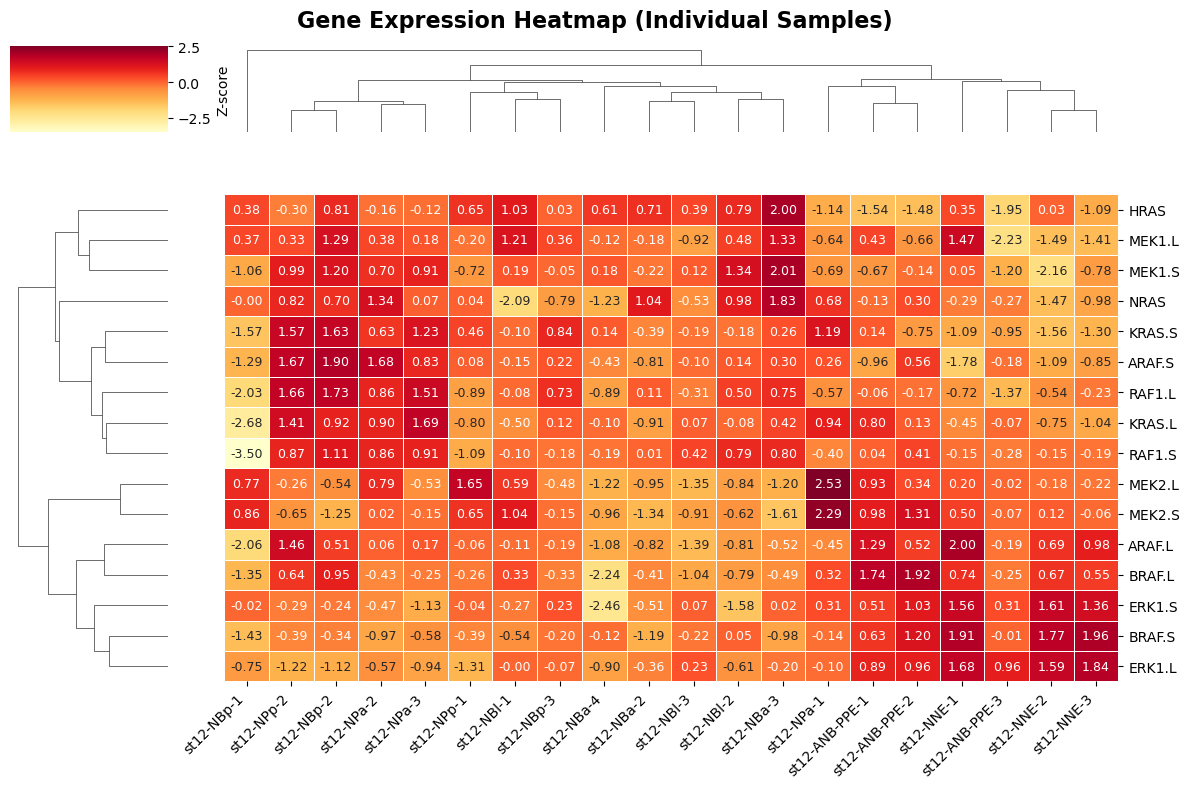


Heatmap saved as: DEG/st12/st12_RAS_pathway_DEG_log__individual_heatmap.png
Clustering applied - Samples: True, Genes: True

STEP 2: Grouping Replicates and Averaging

=== Replicate Grouping ===
Total groups: 7
  st12-ANB-PPE: 3 replicates -> ['st12-ANB-PPE-1', 'st12-ANB-PPE-2', 'st12-ANB-PPE-3']
  st12-NBa: 3 replicates -> ['st12-NBa-2', 'st12-NBa-3', 'st12-NBa-4']
  st12-NBl: 3 replicates -> ['st12-NBl-1', 'st12-NBl-2', 'st12-NBl-3']
  st12-NBp: 3 replicates -> ['st12-NBp-1', 'st12-NBp-2', 'st12-NBp-3']
  st12-NNE: 3 replicates -> ['st12-NNE-1', 'st12-NNE-2', 'st12-NNE-3']
  st12-NPa: 3 replicates -> ['st12-NPa-1', 'st12-NPa-2', 'st12-NPa-3']
  st12-NPp: 2 replicates -> ['st12-NPp-1', 'st12-NPp-2']

Averaged data shape: (19013, 7)

STEP 3: Creating Averaged Heatmap

=== Gene Selection ===
Requested genes: 16
Found genes: 16
  GeneID:399406 -> HRAS
  GeneID:100505423 -> KRAS.L
  GeneID:108712520 -> KRAS.S
  GeneID:399446 -> NRAS
  GeneID:398892 -> ARAF.L
  GeneID:399056 -> ARAF.S
  G

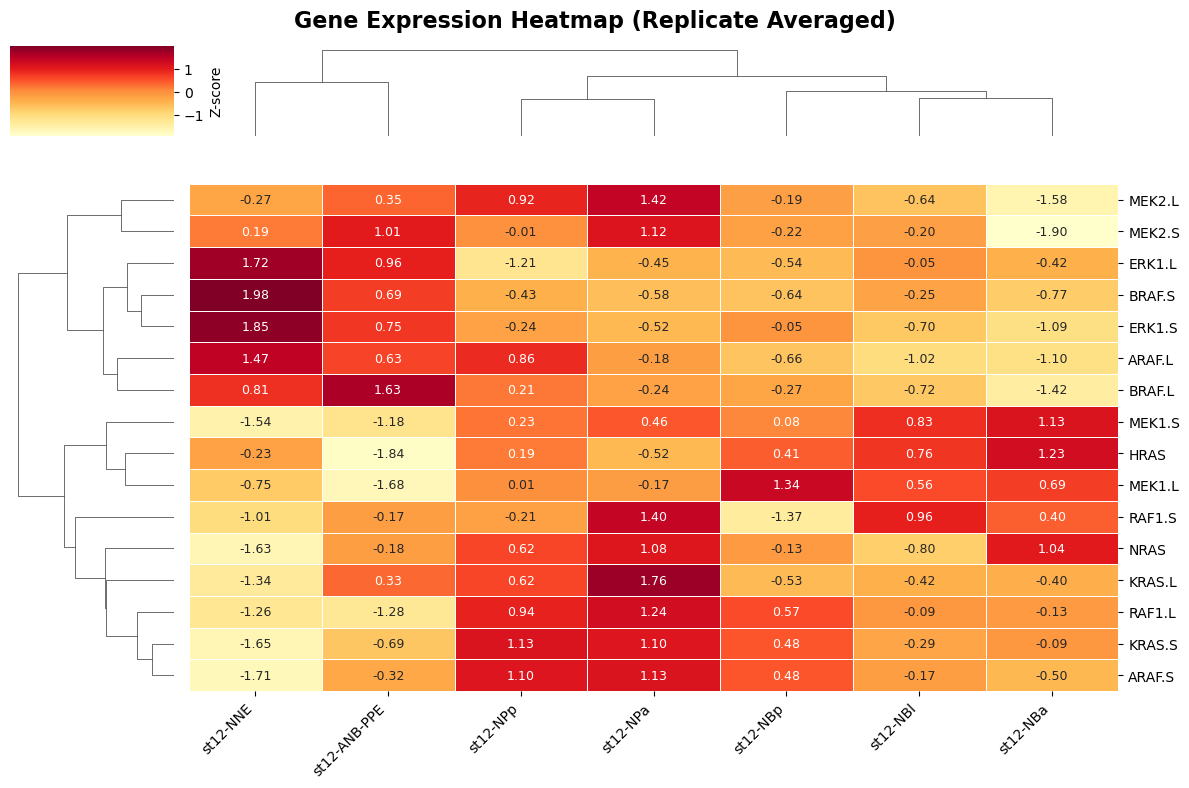


Heatmap saved as: DEG/st12/st12_RAS_pathway_DEG_log__averaged_heatmap.png
Clustering applied - Samples: True, Genes: True

STEP 4: Creating Scatter Plots


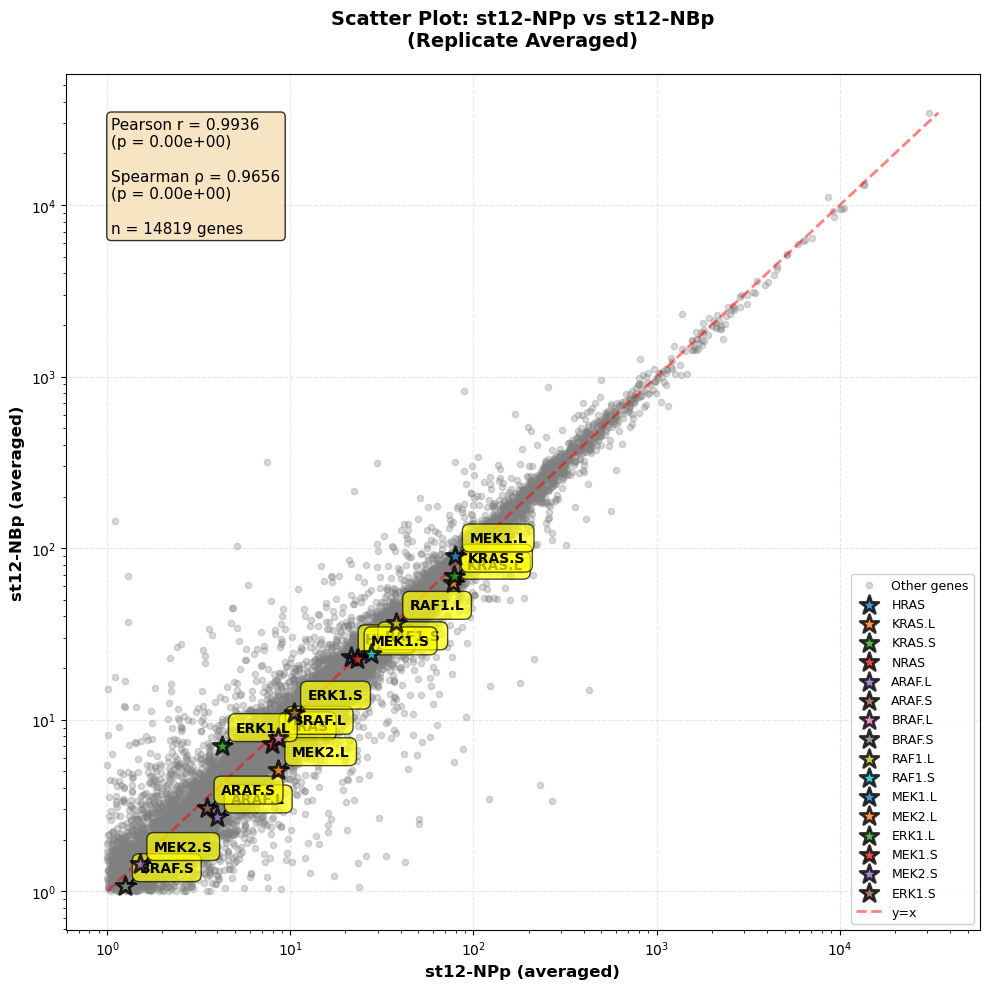


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NPp_vs_st12-NBp.png
  Pearson r = 0.9936, Spearman ρ = 0.9656


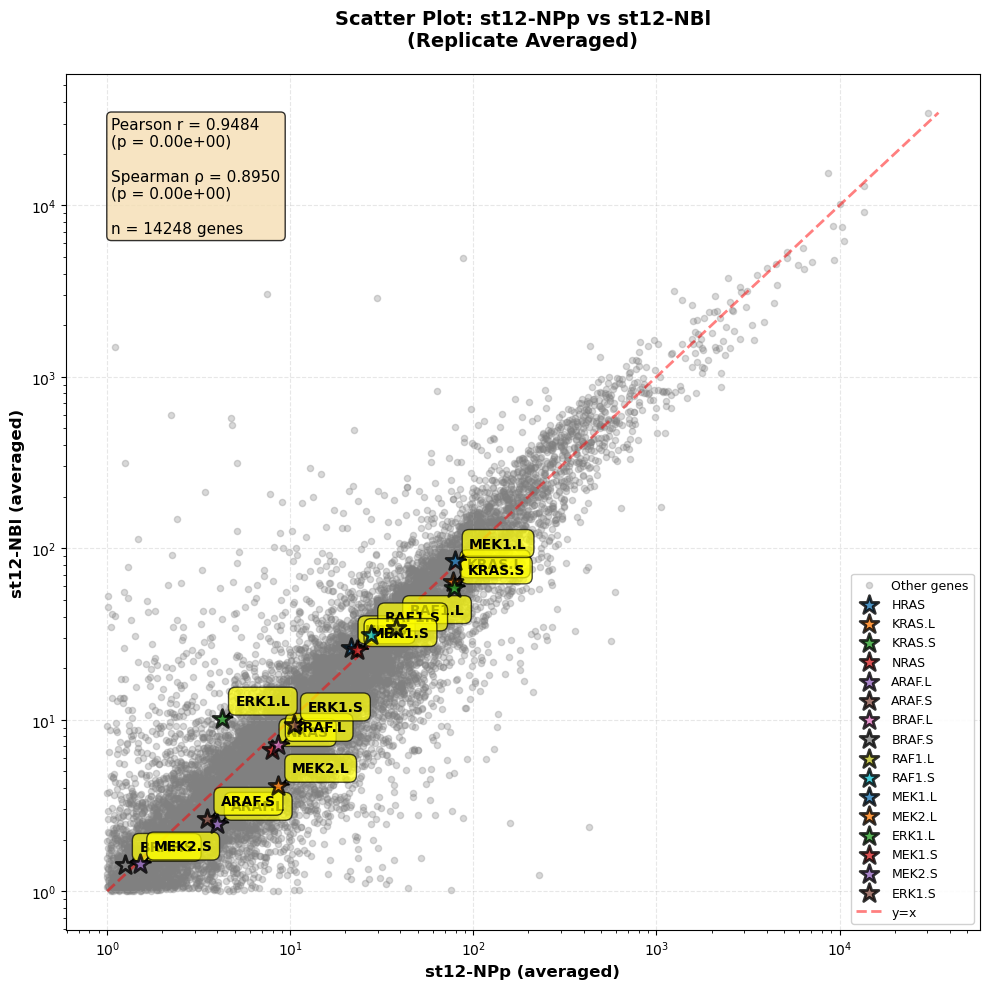


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NPp_vs_st12-NBl.png
  Pearson r = 0.9484, Spearman ρ = 0.8950


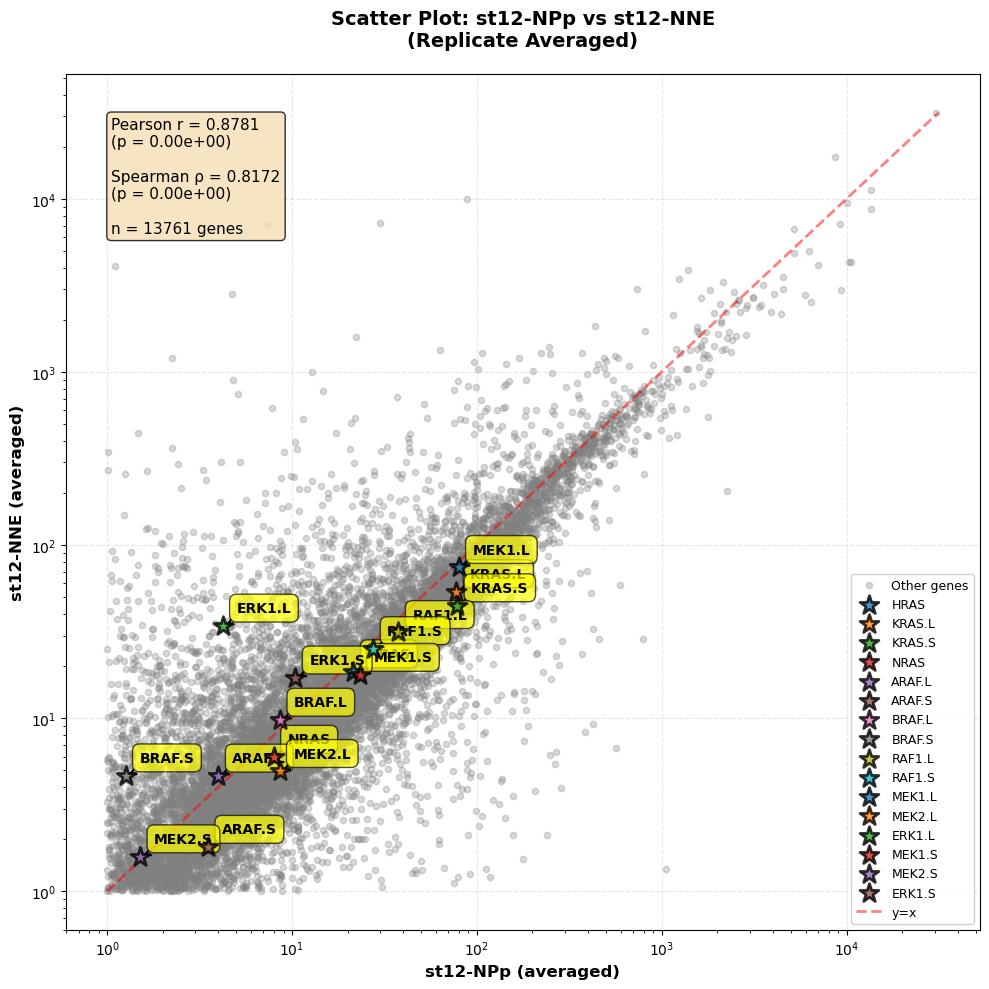


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NPp_vs_st12-NNE.png
  Pearson r = 0.8781, Spearman ρ = 0.8172


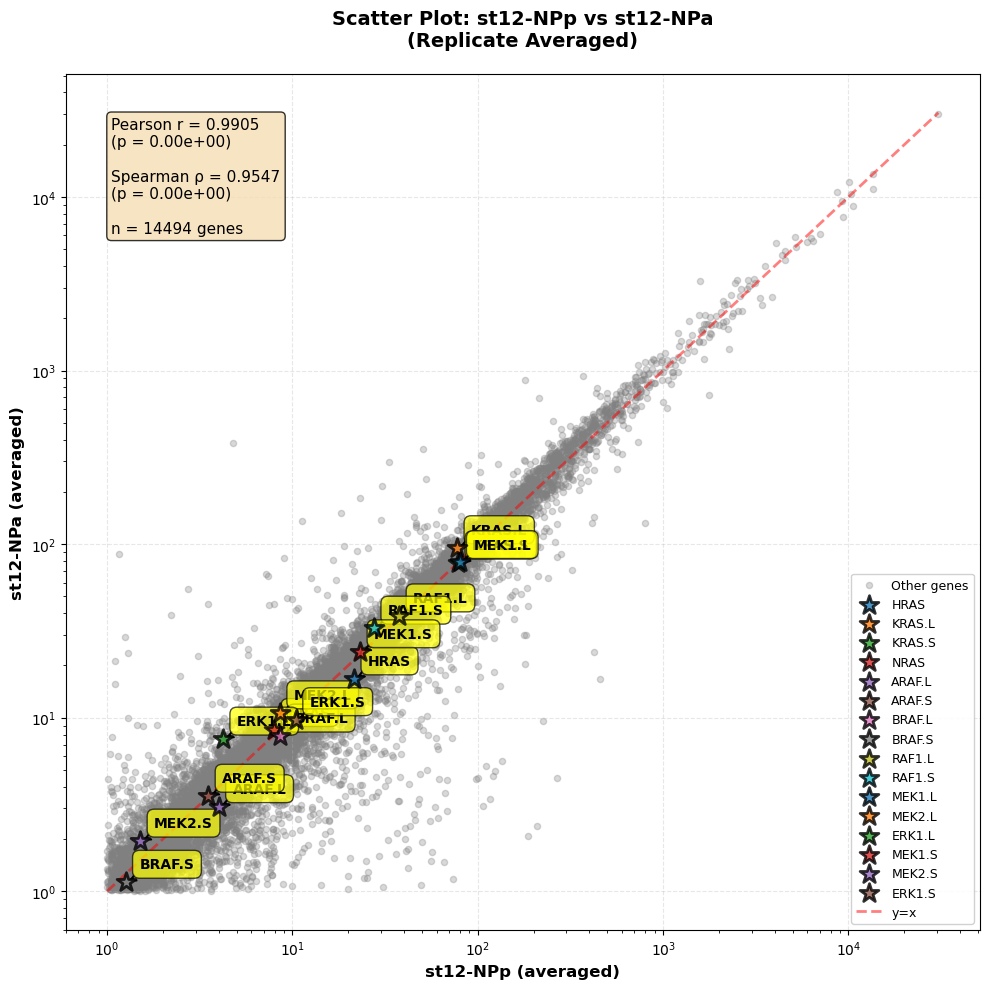


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NPp_vs_st12-NPa.png
  Pearson r = 0.9905, Spearman ρ = 0.9547


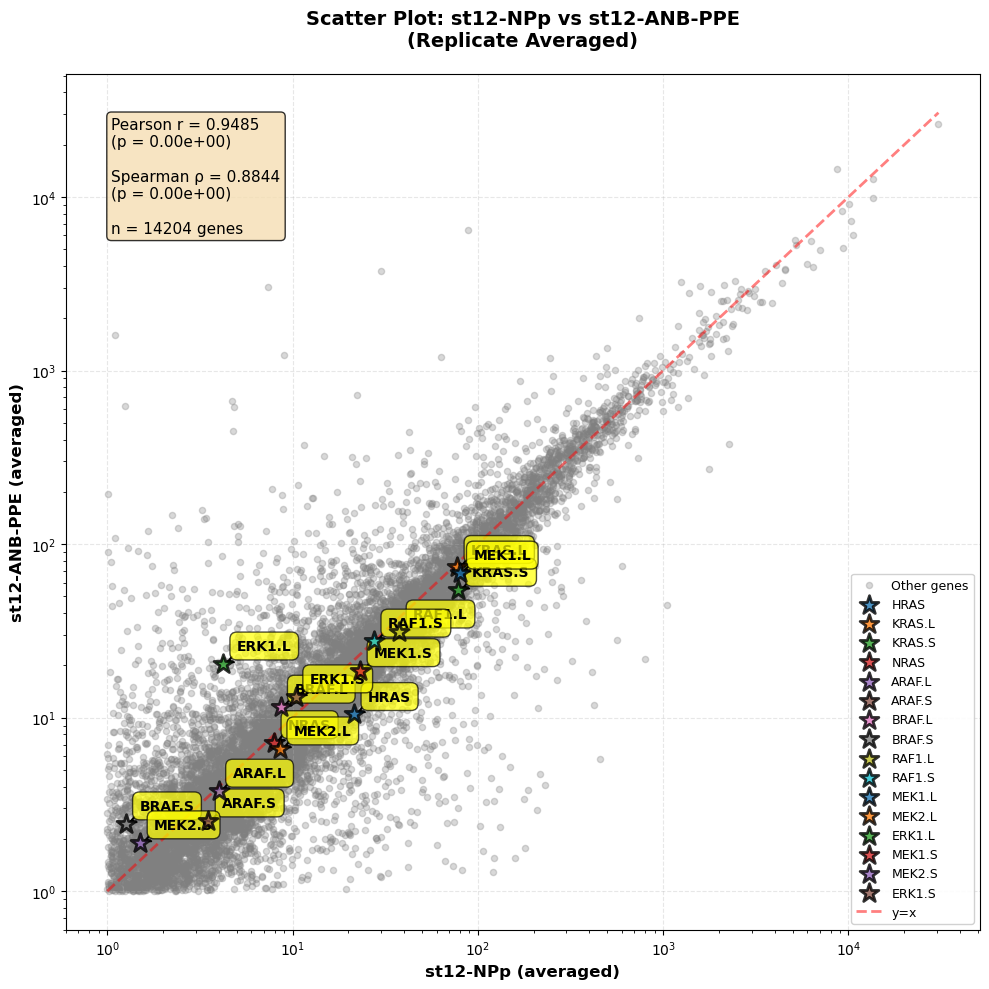


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NPp_vs_st12-ANB-PPE.png
  Pearson r = 0.9485, Spearman ρ = 0.8844


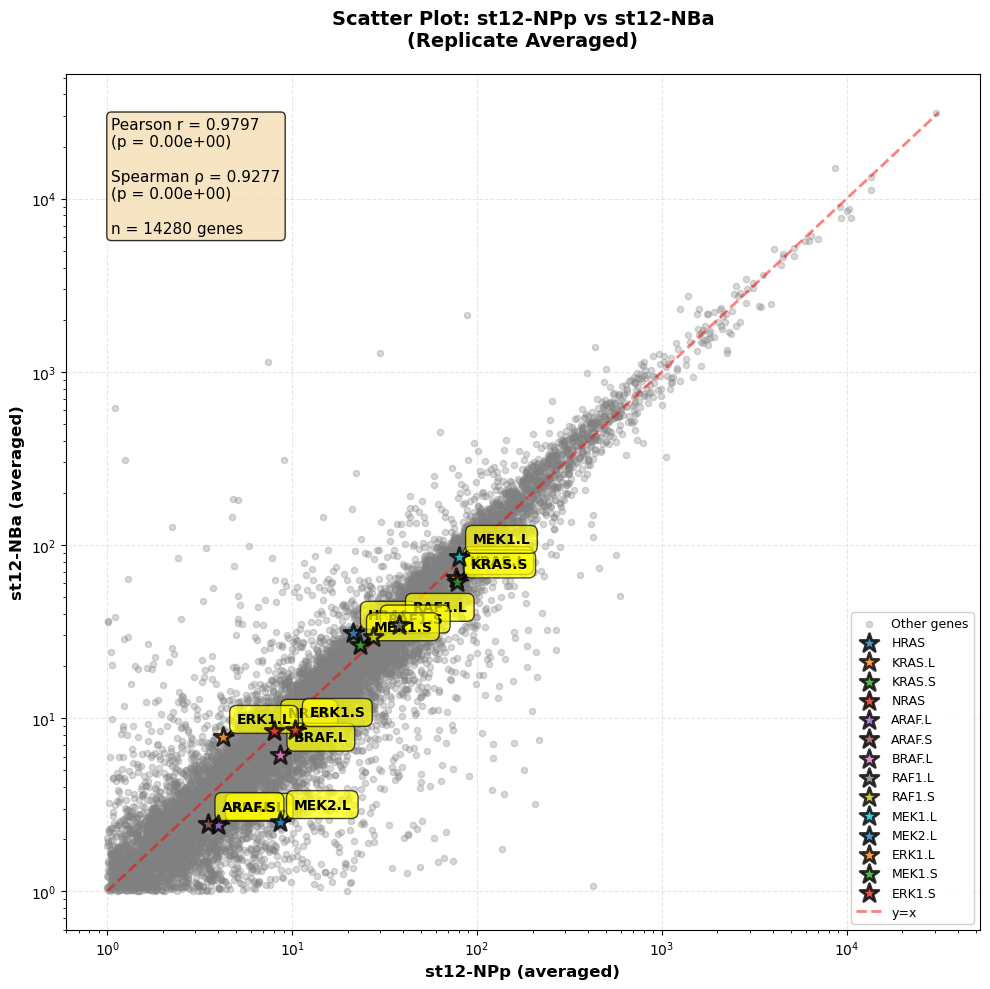


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NPp_vs_st12-NBa.png
  Pearson r = 0.9797, Spearman ρ = 0.9277


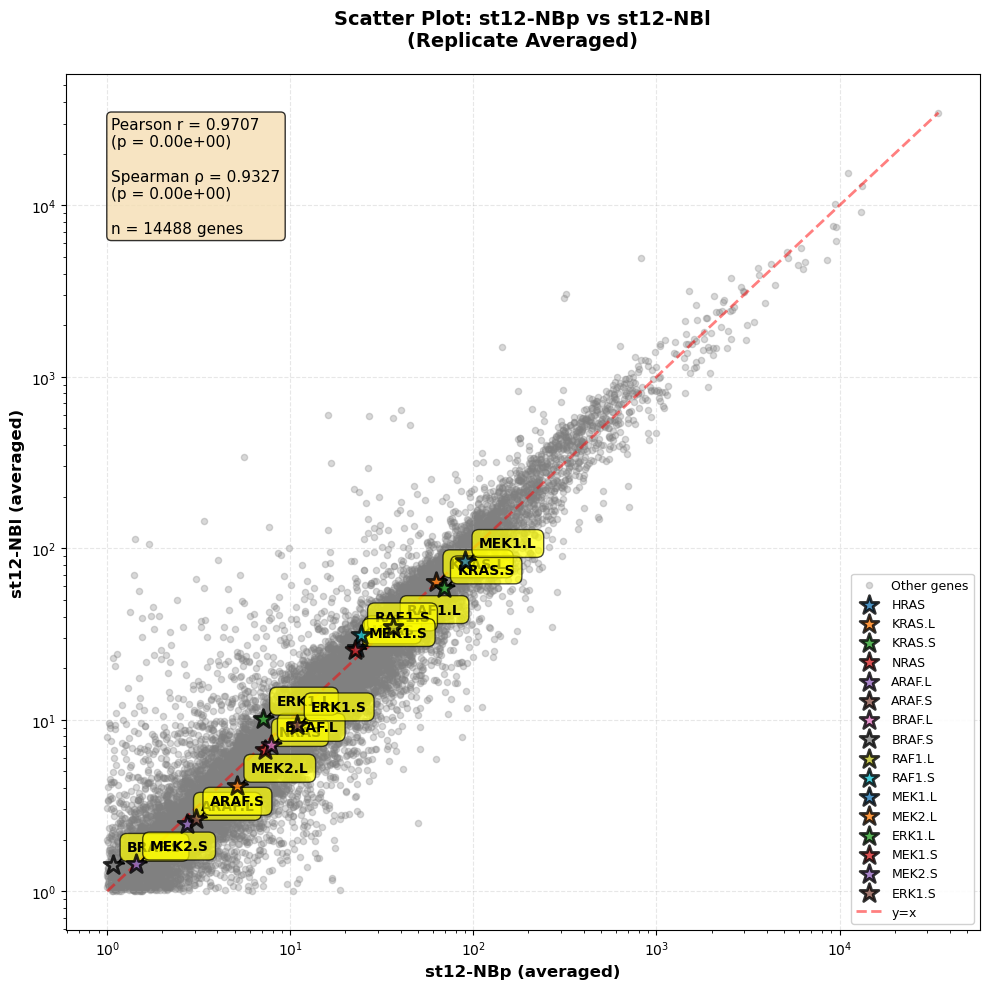


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBp_vs_st12-NBl.png
  Pearson r = 0.9707, Spearman ρ = 0.9327


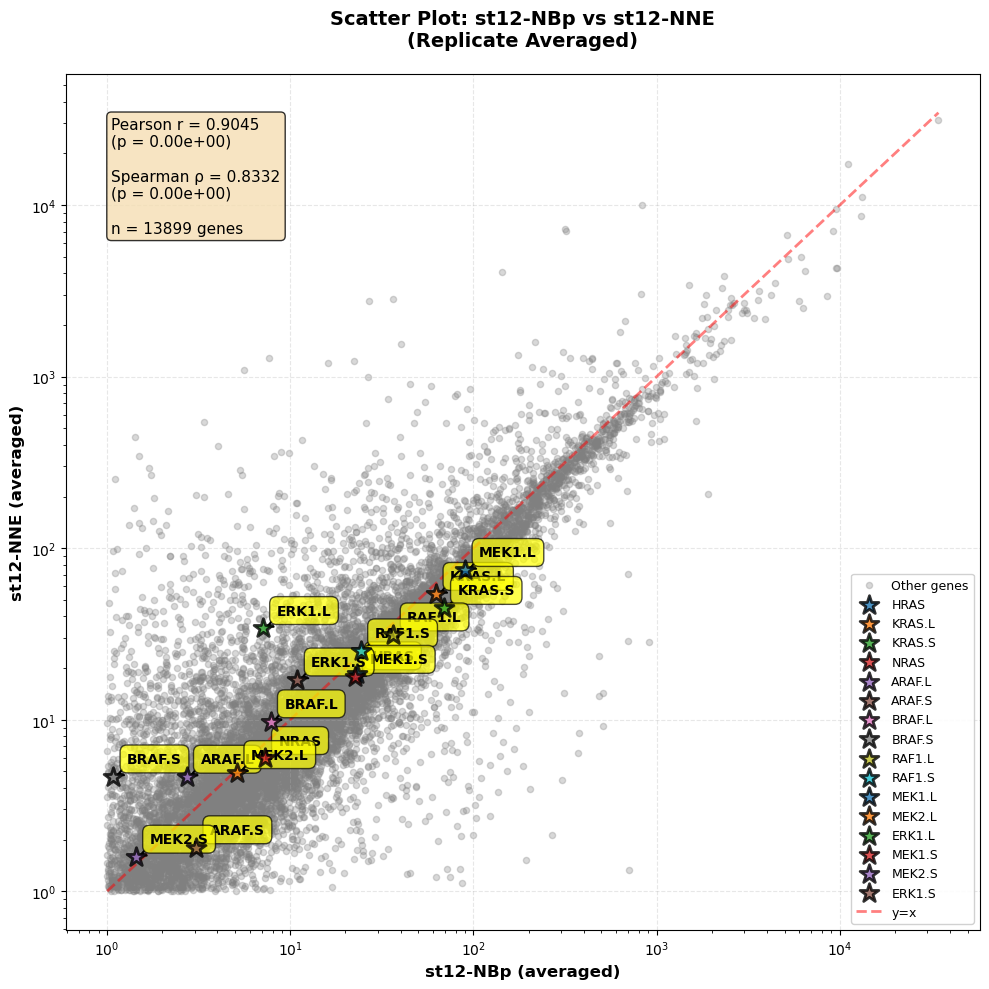


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBp_vs_st12-NNE.png
  Pearson r = 0.9045, Spearman ρ = 0.8332


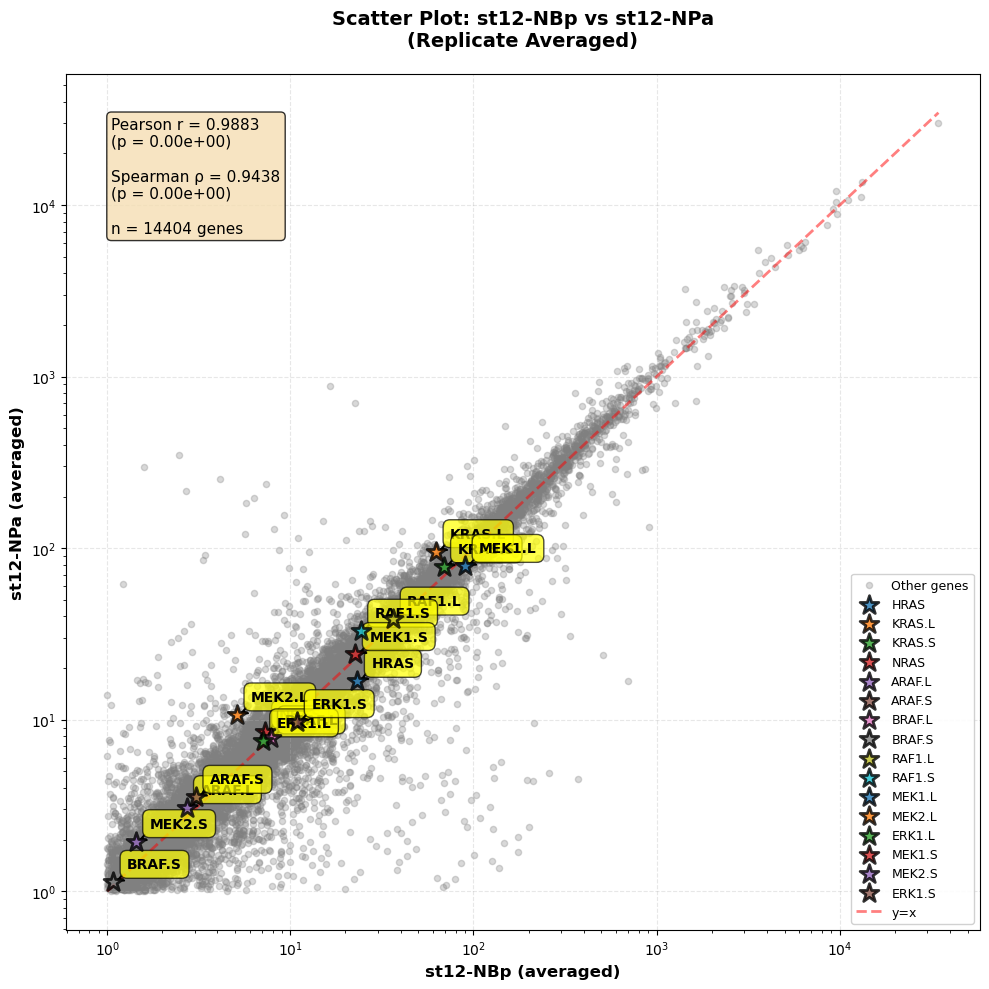


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBp_vs_st12-NPa.png
  Pearson r = 0.9883, Spearman ρ = 0.9438


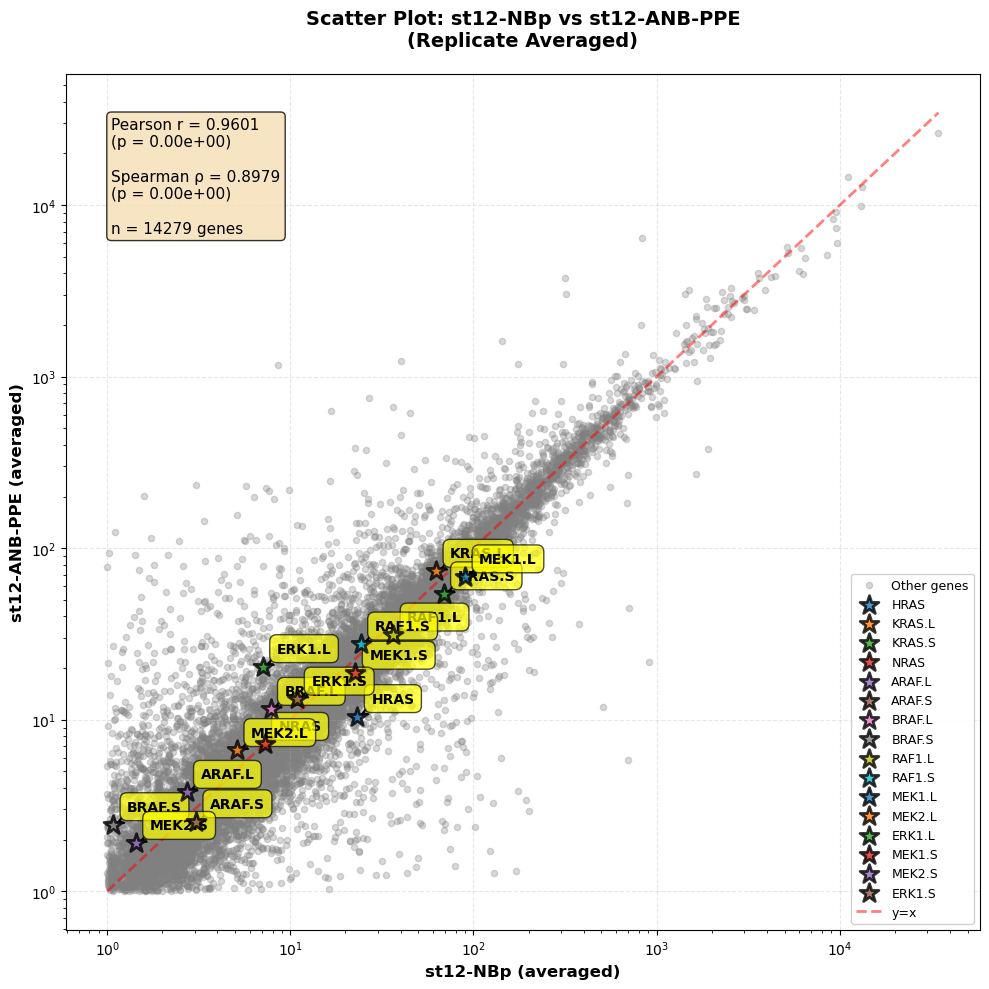


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBp_vs_st12-ANB-PPE.png
  Pearson r = 0.9601, Spearman ρ = 0.8979


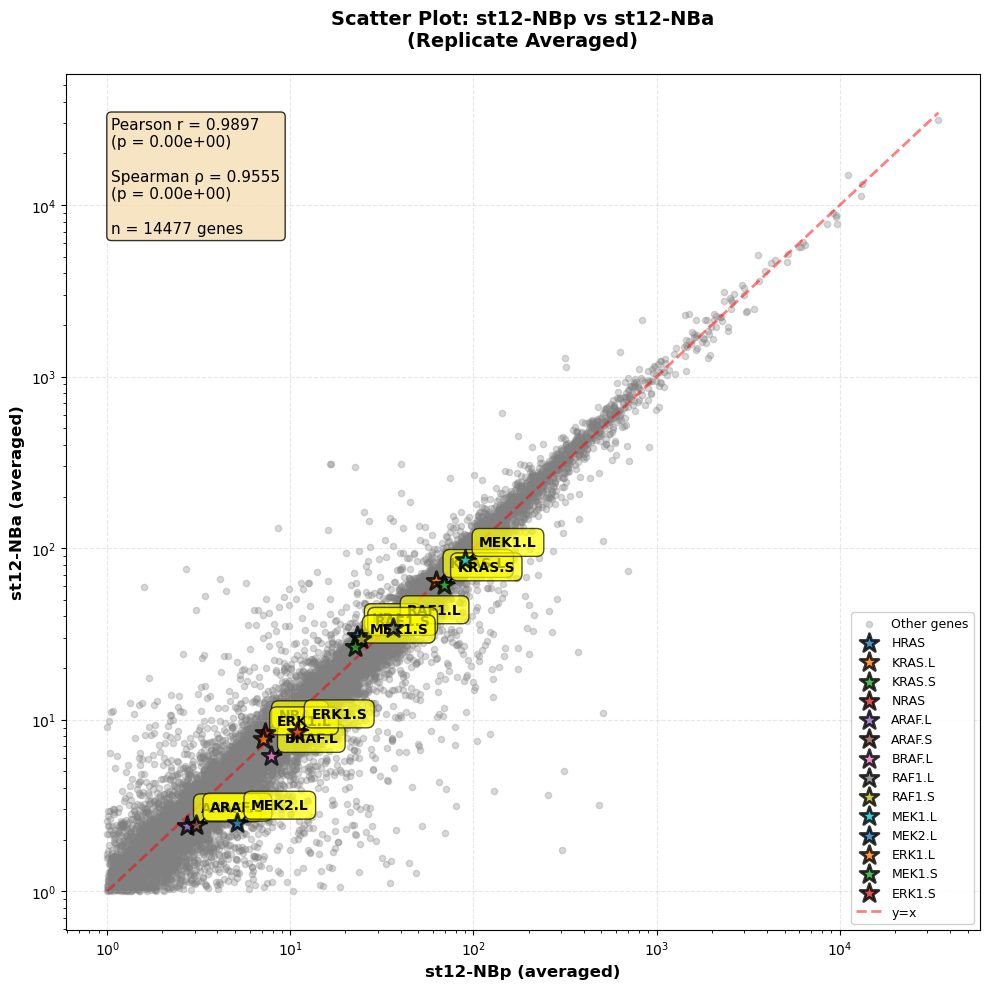


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBp_vs_st12-NBa.png
  Pearson r = 0.9897, Spearman ρ = 0.9555


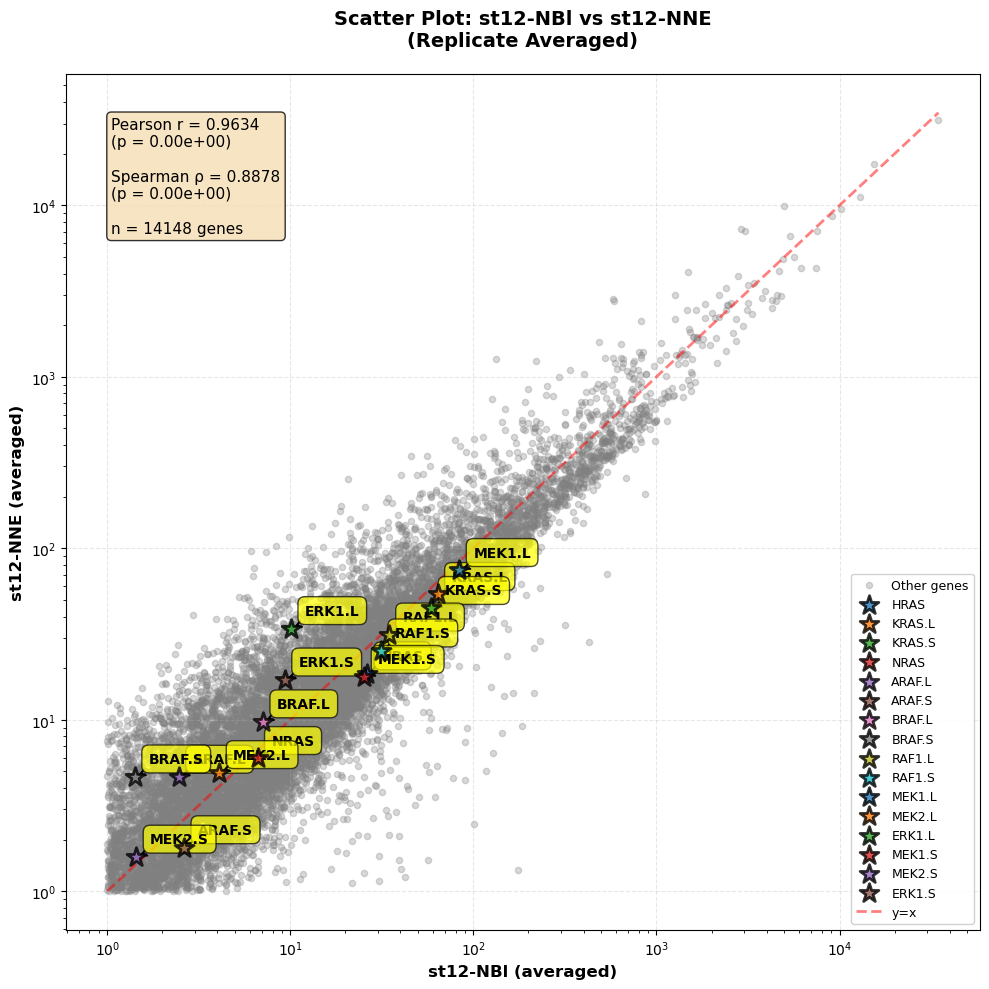


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBl_vs_st12-NNE.png
  Pearson r = 0.9634, Spearman ρ = 0.8878


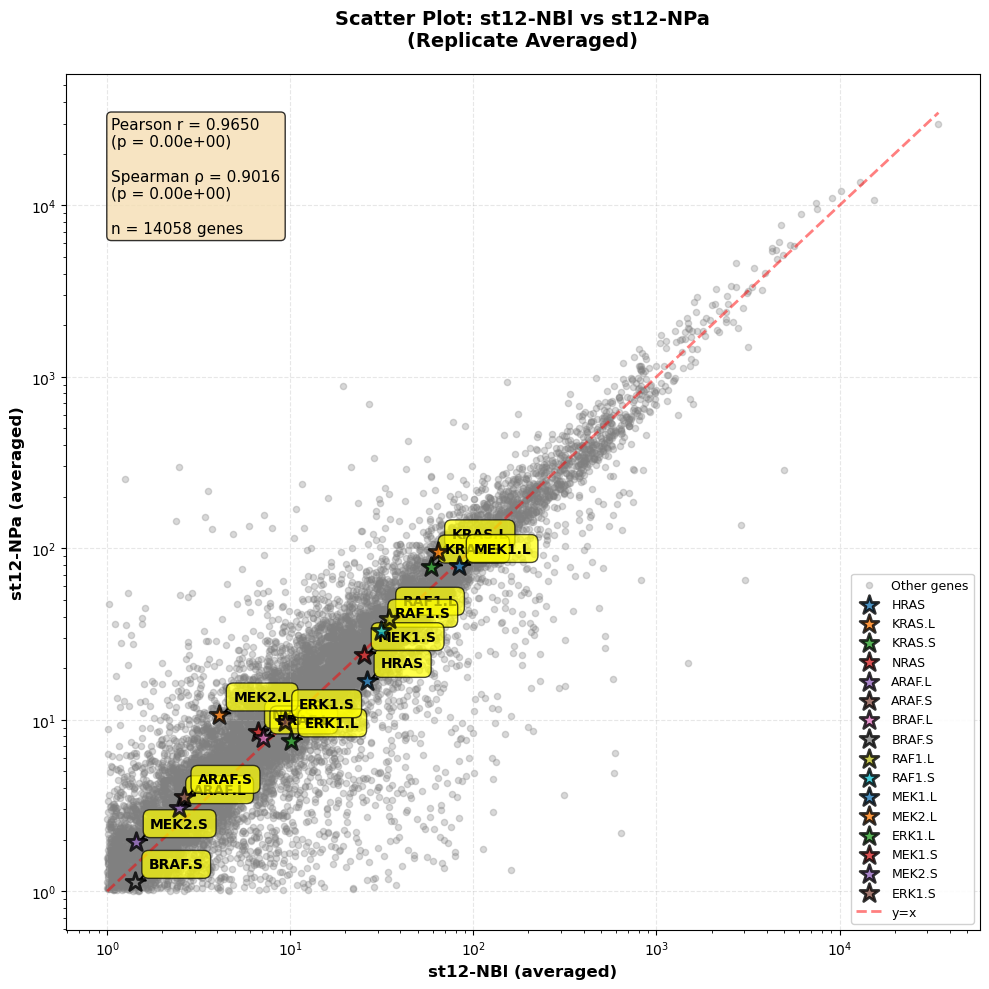


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBl_vs_st12-NPa.png
  Pearson r = 0.9650, Spearman ρ = 0.9016


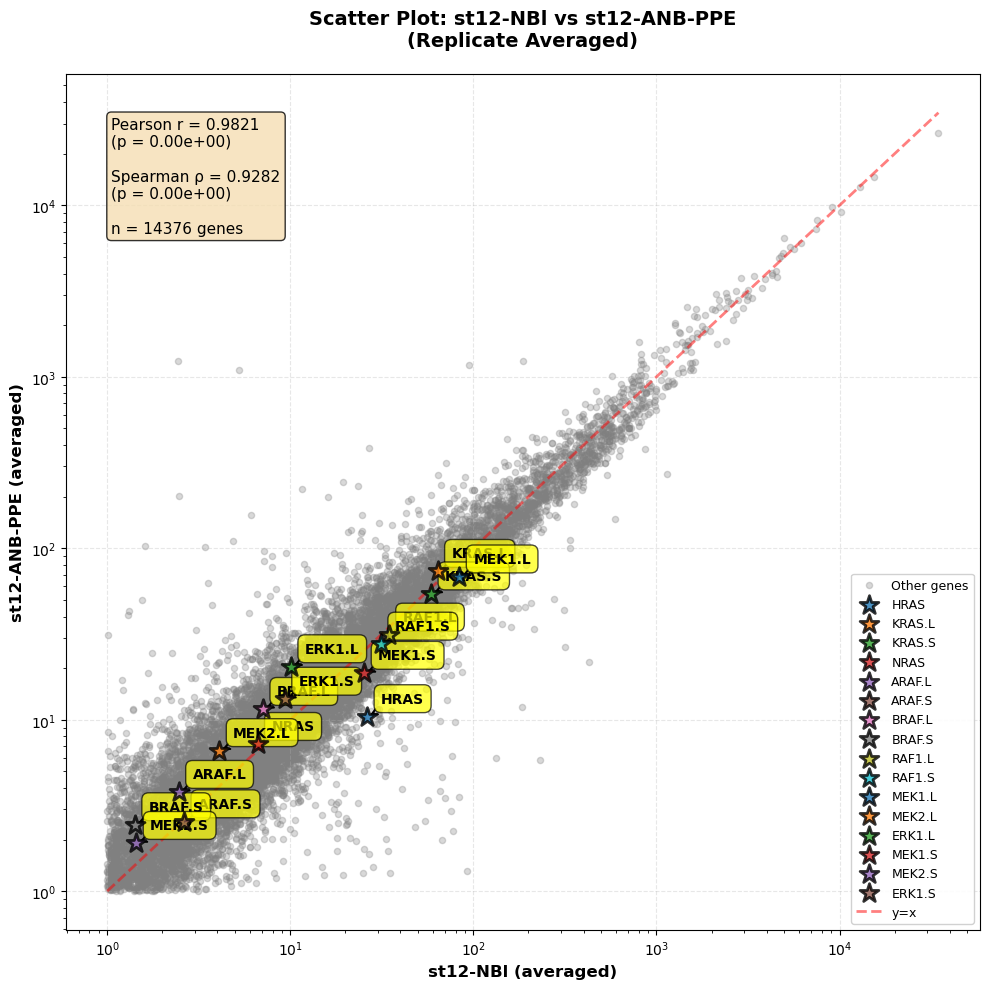


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBl_vs_st12-ANB-PPE.png
  Pearson r = 0.9821, Spearman ρ = 0.9282


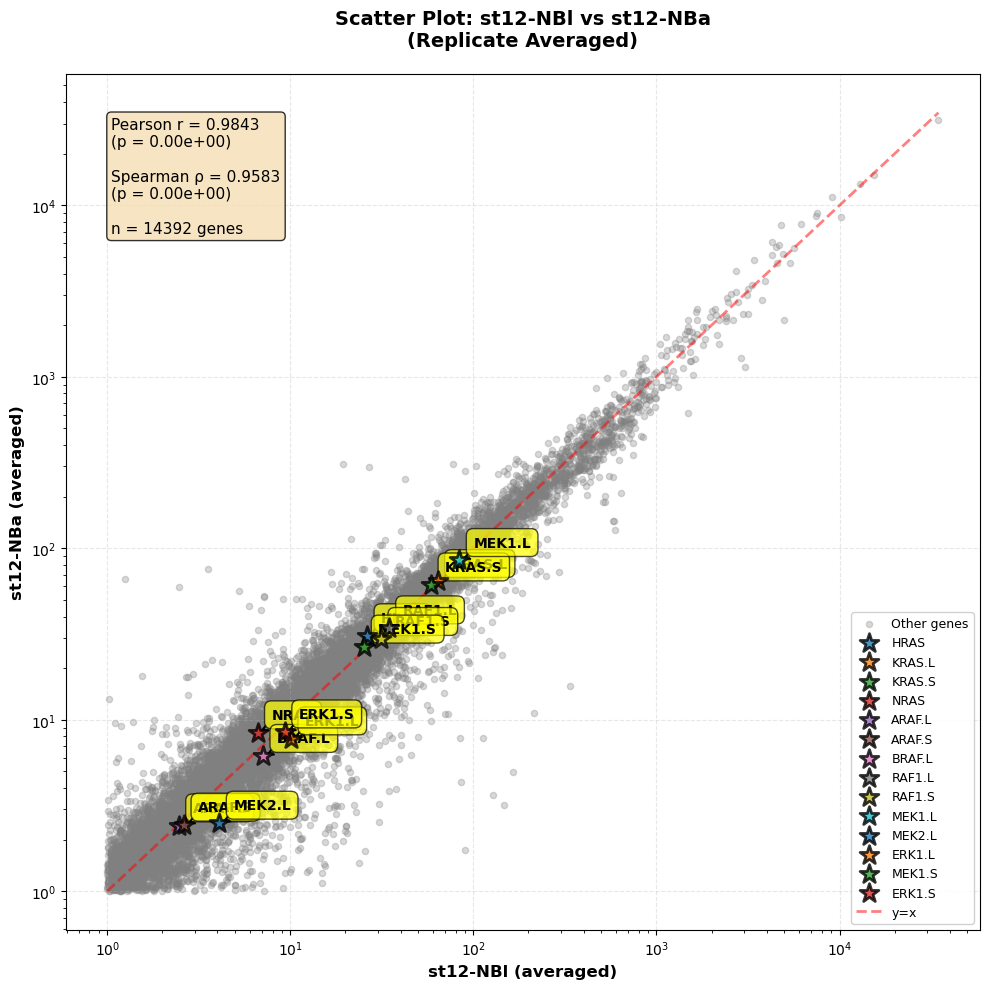


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NBl_vs_st12-NBa.png
  Pearson r = 0.9843, Spearman ρ = 0.9583


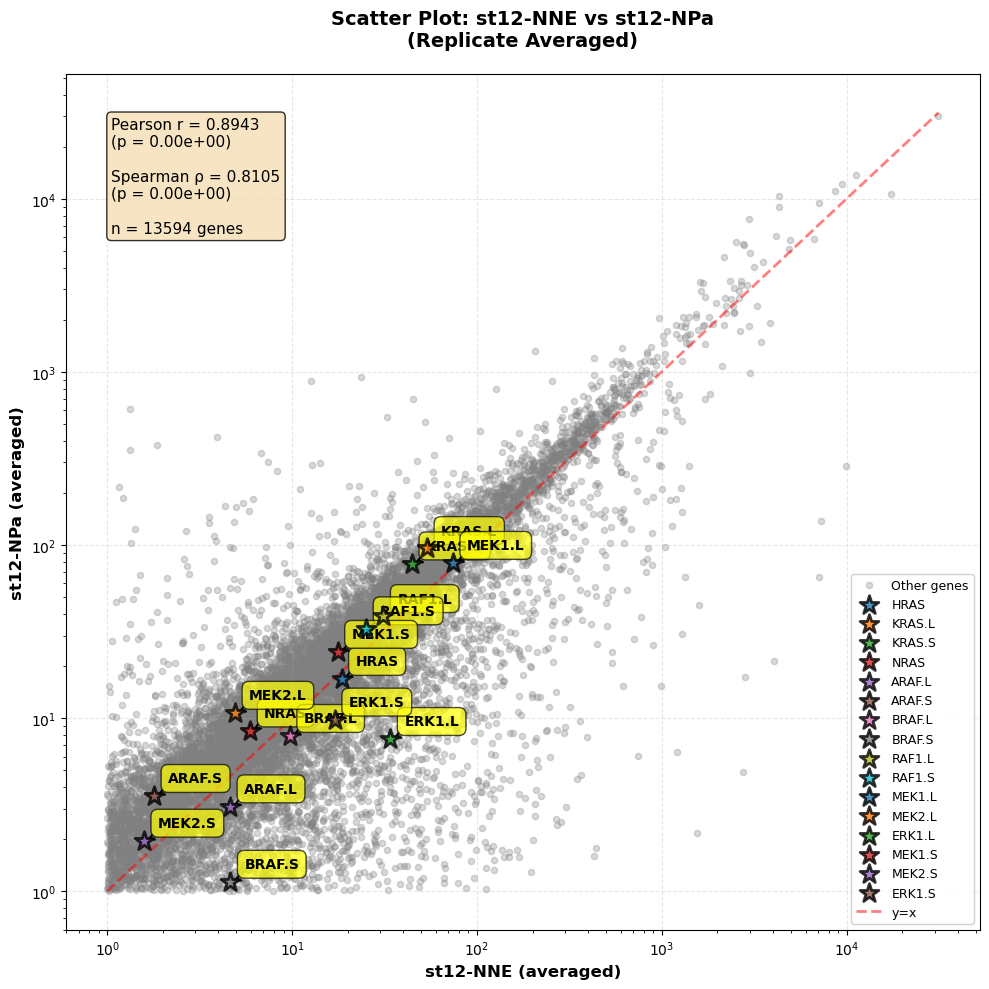


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NNE_vs_st12-NPa.png
  Pearson r = 0.8943, Spearman ρ = 0.8105


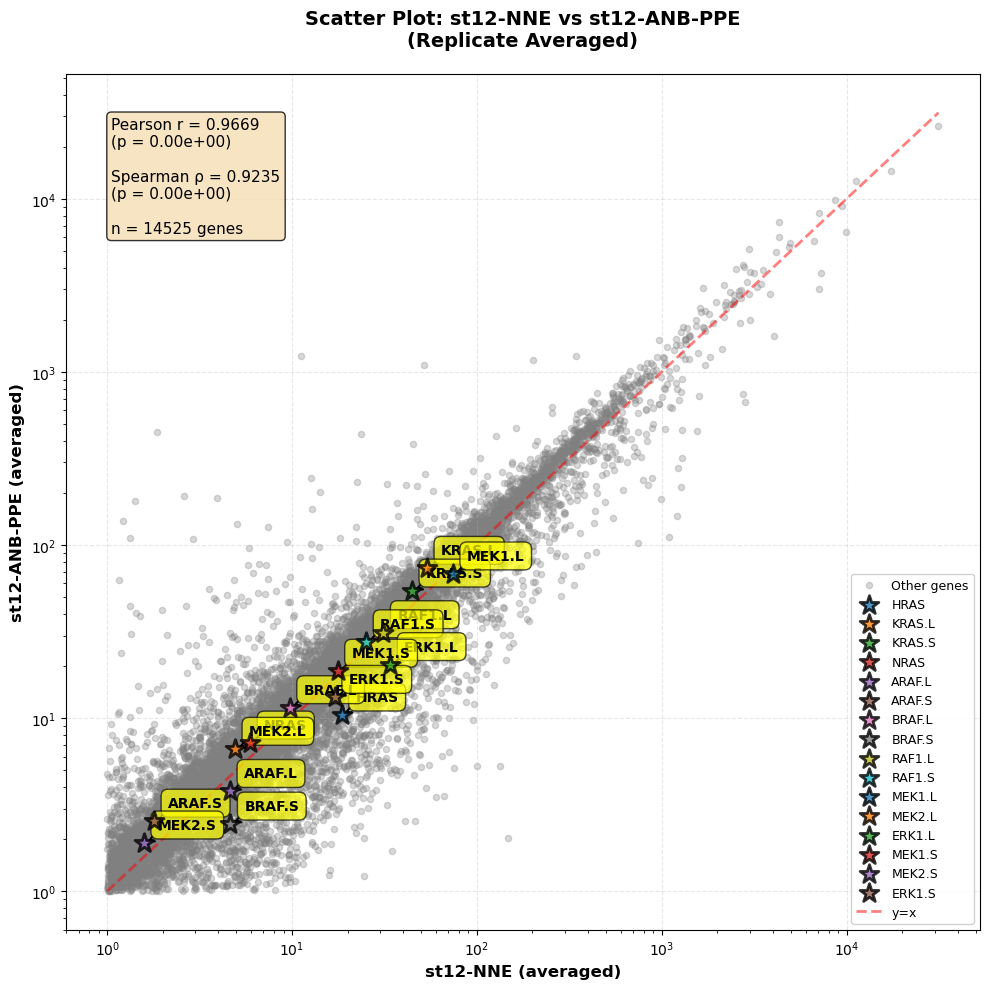


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NNE_vs_st12-ANB-PPE.png
  Pearson r = 0.9669, Spearman ρ = 0.9235


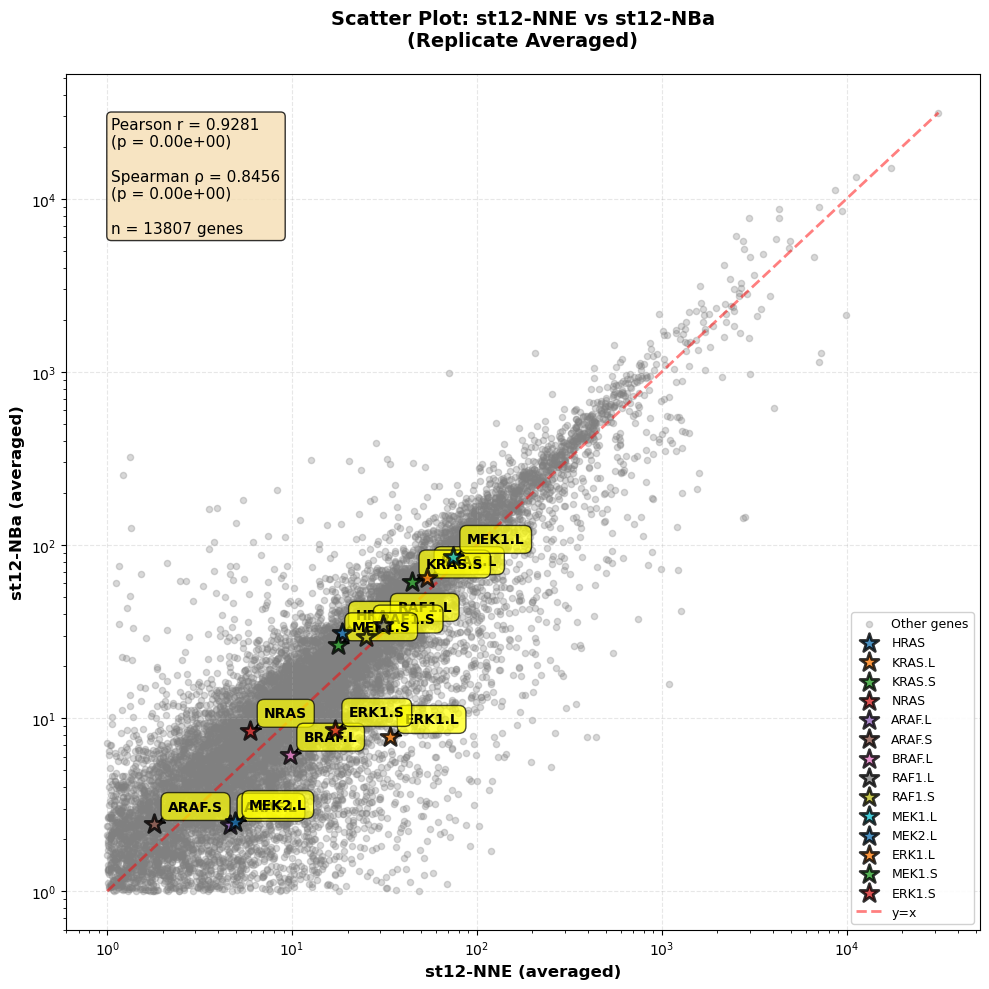


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NNE_vs_st12-NBa.png
  Pearson r = 0.9281, Spearman ρ = 0.8456


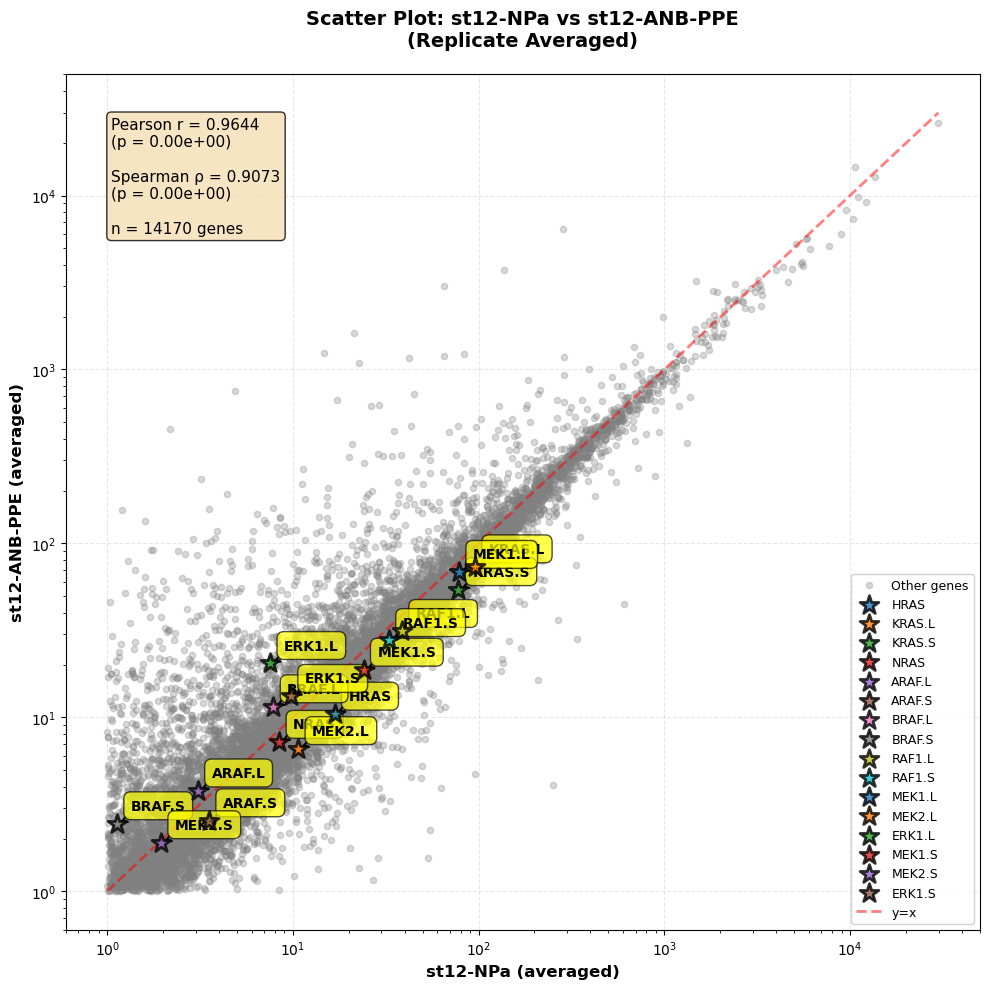


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NPa_vs_st12-ANB-PPE.png
  Pearson r = 0.9644, Spearman ρ = 0.9073


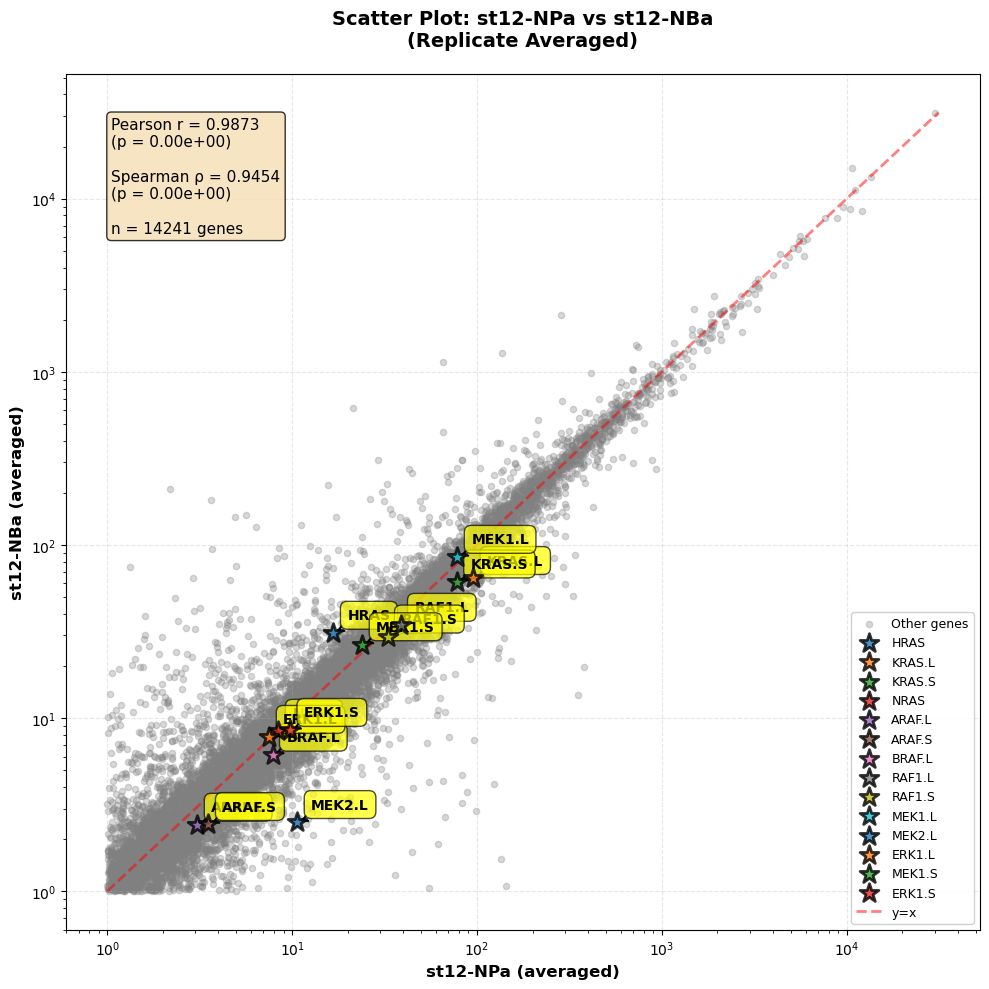


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-NPa_vs_st12-NBa.png
  Pearson r = 0.9873, Spearman ρ = 0.9454


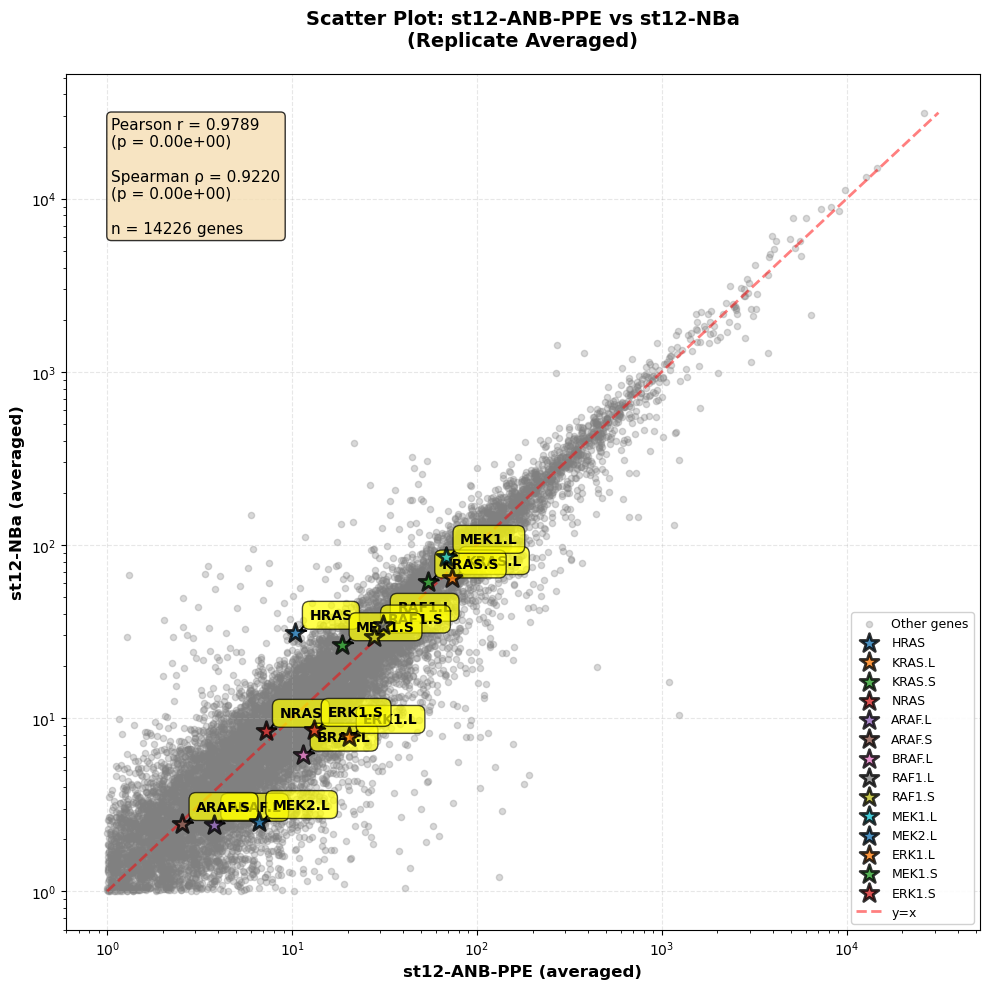


Scatter plot saved as: DEG/st12/st12_RAS_pathway_DEG_log__scatter_st12-ANB-PPE_vs_st12-NBa.png
  Pearson r = 0.9789, Spearman ρ = 0.9220

Analysis Complete!


In [54]:
#samples_to_exclude = ['st14-NPa-2', 'st14-NBp-1','st14-NBp-2','st14-NBa-3','st14-NBa-2','st14-NBa-1', 'st14-ANF-PPE-1']  # 제외할 샘플
df_orig = rename_sample_columns(input_file='./DEG/merged_tpm_data_12.csv')
df_filtered = filter_genes_low(df_orig)
samples_to_exclude = ['st12-NPp-3', 'st12-NBa-1']  # 제외할 샘플
gene_dict = {
    "399406": "HRAS",
    "100505423": "KRAS.L",
    "108712520": "KRAS.S",
    "399446": "NRAS",
    "398892": "ARAF.L",
    "399056": "ARAF.S",
    "447268": "BRAF.L",
    "398973": "BRAF.S",
    "108704012": "RAF1.L",
    "397857": "RAF1.S",
    "379991": "MEK1.L",
    "399471": "MEK2.L",
    "397785": "ERK1.L",
    "108712802": "MEK1.S",
    "431908": "MEK2.S",
    "398985": "ERK1.S"
} # 분석할 유전자
# 
df_filtered, df_averaged, groups = complete_workflow(
     df_filtered, 
     samples_to_exclude, 
     gene_dict,
     output_prefix='DEG/st12/st12_RAS_pathway_DEG_log_',
     cluster_heatmaps=True,
     zscore=True
)

In [48]:

# 예시 1: 전체 워크플로우 실행
#samples_to_exclude = ['st14-NPa-2', 'st14-NBp-1','st14-NBp-2','st14-NBa-3','st14-NBa-2','st14-NBa-1', 'st14-ANF-PPE-1']  # 제외할 샘플
gene_dict = {
    "399406": "HRAS",
    "100505423": "KRAS.L",
    "108712520": "KRAS.S",
    "399446": "NRAS",
    "398892": "ARAF.L",
    "399056": "ARAF.S",
    "447268": "BRAF.L",
    "398973": "BRAF.S",
    "108704012": "RAF1.L",
    "397857": "RAF1.S",
    "379991": "MEK1.L",
    "399471": "MEK2.L",
    "397785": "ERK1.L",
    "108712802": "MEK1.S",
    "431908": "MEK2.S",
    "398985": "ERK1.S"
} # 분석할 유전자
# 
df_filtered, df_averaged, groups = complete_workflow(
     df_filtered, 
     #samples_to_exclude, 
     gene_dict,
     output_prefix='st14_RAS_pathway',
     cluster_heatmaps=True  
)
# 예시 2: 단계별 실행
# # Step 1: 샘플 제외
# samples_to_exclude = ['st12-NPp-1', 'st12-NBp-3']
# df_filtered = exclude_samples(df, samples_to_exclude)
# 
# # Step 2: 개별 샘플 heatmap
# gene_list = ["399406", "100505423", "108712520", "399446"]
# plot_expression_heatmap(df_filtered, gene_list, 
#                        output_file='individual_heatmap.png')
# 
# # Step 3: Replicate 평균
# df_averaged, groups = group_replicates(df_filtered)
# 
# # Step 4: 평균 데이터 heatmap
# plot_expression_heatmap(df_averaged, gene_list,
#                        output_file='averaged_heatmap.png')
# 
# # Step 5: 특정 두 그룹 scatter plot
# plot_grouped_scatter(df_averaged, 'st12-NPp', 'st12-NBp',
#                     gene_list=gene_list,
#                     output_file='scatter_NPp_vs_NBp.png')

TypeError: complete_workflow() missing 1 required positional argument: 'gene_list'